# Classification: MAGIC Gamma Telescope

Comparing several classification models — KNN, Naive Bayes, SVM, and a Neural Network — on the [MAGIC Gamma Telescope dataset](https://www.kaggle.com/datasets/abhinand05/magic-gamma-telescope-dataset), predicting whether a detected shower was caused by a gamma ray or a hadron from 10 numeric features.

In [8]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

*Process* — downloads the MAGIC Gamma Telescope dataset via `kagglehub` and loads it into `df`. *Observation* — the preview below shows 10 numeric feature columns (`fLength` through `fDist`) plus a `class` label (`g` for gamma, presumably `h` for hadron elsewhere in the data).

In [10]:
path = kagglehub.dataset_download("abhinand05/magic-gamma-telescope-dataset")
print(path)  # local cache path where files were placed

df = pd.read_csv(f"{path}/telescope_data.csv", index_col=0)
df.head()

/Users/macmin/.cache/kagglehub/datasets/abhinand05/magic-gamma-telescope-dataset/versions/1


,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


*Process* — pulls out just the column names into a plain list (`cols`), for reuse in the labeling loop and later slicing (`cols[:-1]`). *Observation* — confirms the 10 feature names plus the `class` label at the end.

In [11]:
cols = df.columns.tolist()
print(cols)

['fLength', 'fWidth', 'fSize', 'fConc', 'fConc1', 'fAsym', 'fM3Long', 'fM3Trans', 'fAlpha', 'fDist', 'class']


*Process* — converts the string `class` column (`"g"`/`"h"`) into a binary integer label: `1` for gamma, `0` for hadron. Needed since scikit-learn/Keras models require numeric targets, not strings.

In [12]:
df["class"] = (df["class"] == "g").astype(int)

*Process* — for each feature, overlays a normalized histogram of gamma events (blue) against hadron events (red), a quick way to visually scan which features actually separate the two classes. *Observation* — features where the blue and red histograms barely overlap (e.g. `fAlpha`, `fConc`) are strong discriminators; features where they largely coincide contribute less separating power on their own.

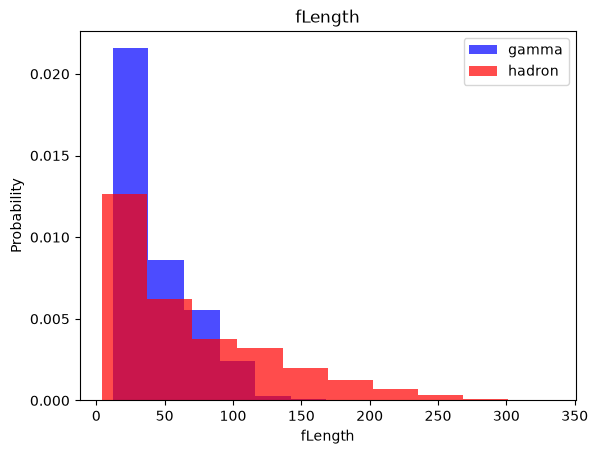

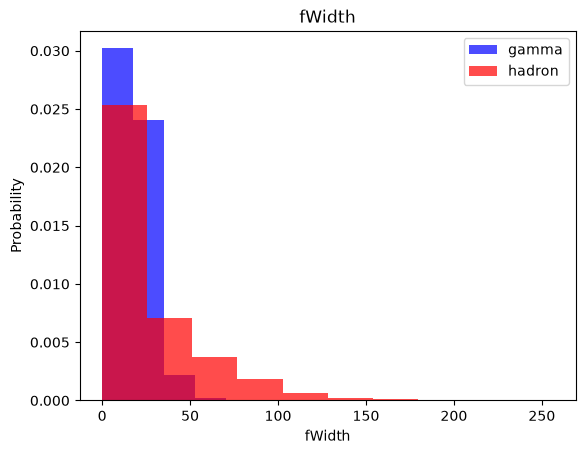

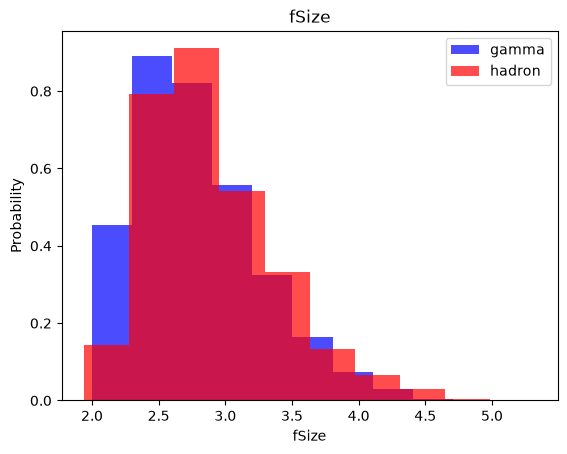

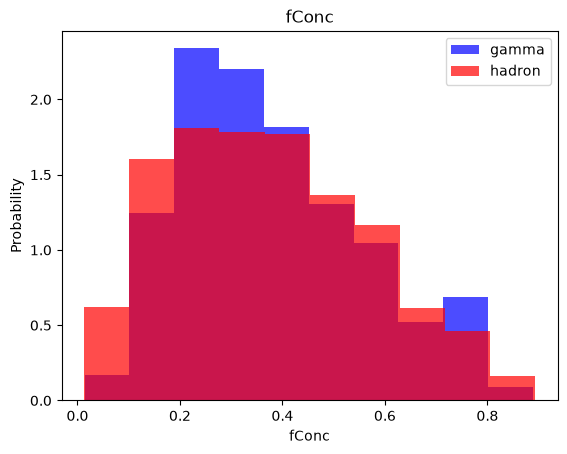

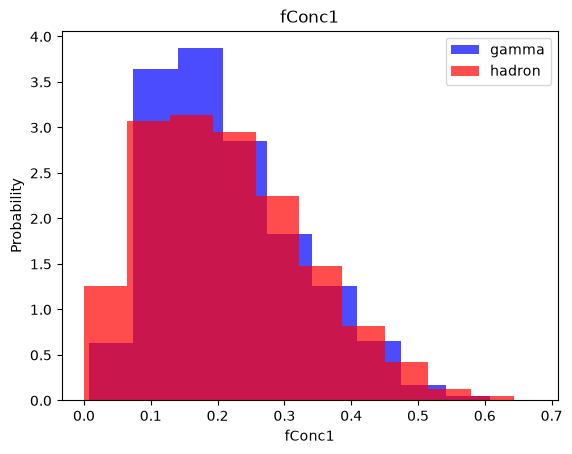

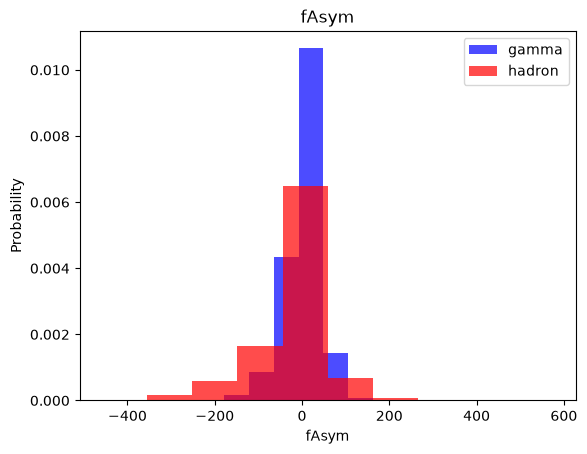

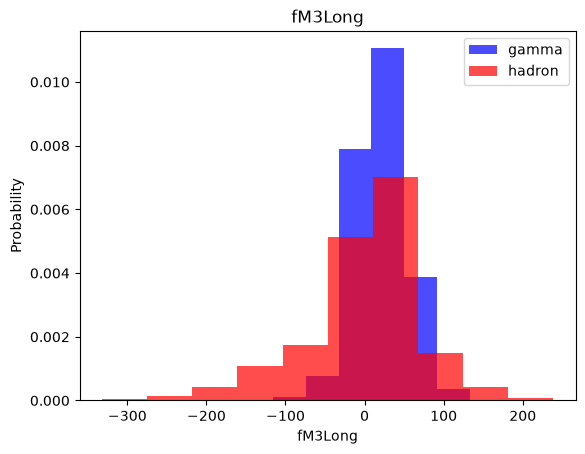

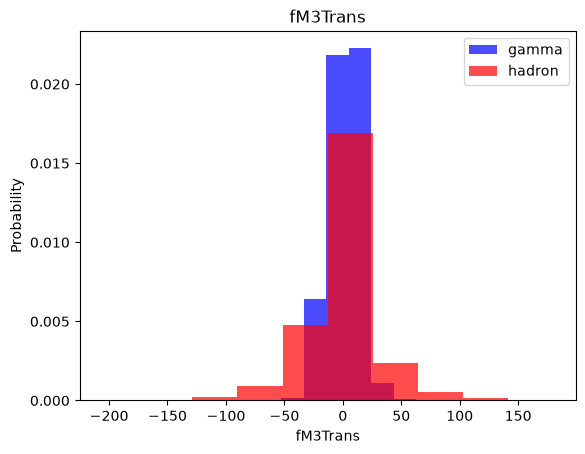

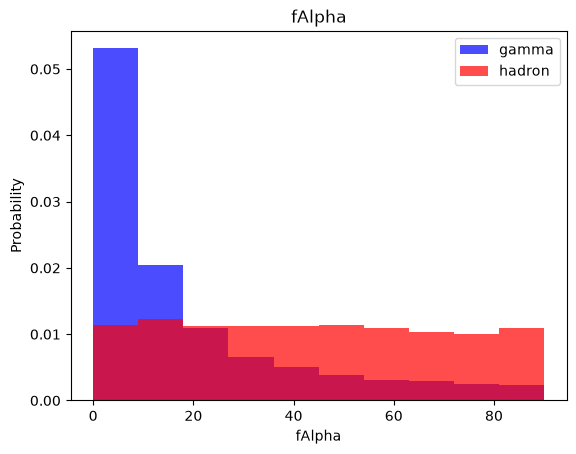

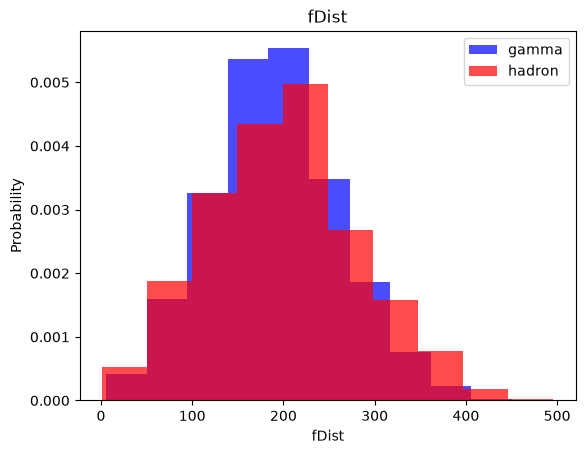

In [13]:
for label in cols[:-1]:
  plt.hist(df[df["class"]==1][label], color='blue', label='gamma', alpha=0.7, density=True)
  plt.hist(df[df["class"]==0][label], color='red', label='hadron', alpha=0.7, density=True)
  plt.title(label)
  plt.ylabel("Probability")
  plt.xlabel(label)
  plt.legend()
  plt.show()
  

# Train, validation, test datasets

*Process* — shuffles the full dataset (`df.sample(frac=1)`) then slices it into 60% train / 20% valid / 20% test by row position. No scaling or oversampling applied yet — that happens later in `scale_dataset`.

In [14]:
df = df.sample(frac=1)
n = len(df)
train = df.iloc[:int(0.6 * n)]
valid = df.iloc[int(0.6 * n):int(0.8 * n)]
test = df.iloc[int(0.8 * n):]

*Process* — defines `scale_dataset`, which standardizes features with `StandardScaler` (zero mean, unit variance — needed since KNN/SVM/NN are all sensitive to feature scale), optionally oversamples the minority class with `RandomOverSampler`, and returns both a combined array and the separate `X`/`y` splits for convenience.

In [15]:
def scale_dataset(dataframe, oversample=False):
  X = dataframe[dataframe.columns[:-1]].values
  y = dataframe[dataframe.columns[-1]].values

  scaler = StandardScaler()
  X = scaler.fit_transform(X)

  if oversample:
    ros = RandomOverSampler()
    X, y = ros.fit_resample(X, y)

  # take two arrays and horizontally stack them together
  #-1,1 -> make it into 2d array. 
  data = np.hstack((X, np.reshape(y, (-1, 1))))

  return data, X, y

*Process* — checks class balance in the raw (unscaled) training split. *Observation* — output shows 7,415 gamma vs. 3,997 hadron samples: roughly 65/35, a moderate imbalance — this is the motivation for the `oversample=True` call on `train` a couple cells below.

In [16]:
print(len(train[train["class"] == 1]))  # gamma
print(len(train[train["class"] == 0]))  # hadron

7415
3997


#### Oversample training dataset. 

*Process* — the `isinstance` guard defensively re-creates `train`/`valid`/`test` if they were previously overwritten (e.g. from re-running `scale_dataset` on them earlier in the session, which returns arrays, not DataFrames). Then applies `scale_dataset` to each split — `oversample=True` only on `train` (to fix the 65/35 imbalance seen above), never on `valid`/`test` (those must reflect real-world class proportions for an honest evaluation).

In [17]:
# Guard: re-create splits if train was overwritten to a numpy array
if not isinstance(train, pd.DataFrame):
    df = df.sample(frac=1)
    n = len(df)
    train = df.iloc[:int(0.6 * n)]
    valid = df.iloc[int(0.6 * n):int(0.8 * n)]
    test  = df.iloc[int(0.8 * n):]

train, X_train, y_train = scale_dataset(train, oversample=True)
valid, X_valid, y_valid = scale_dataset(valid, oversample=False)
test,  X_test,  y_test  = scale_dataset(test,  oversample=False)

## Model 1: KNN

*Process* — defines and calls `knn_predict`, which fits a `KNeighborsClassifier` with a given `k` on the scaled/oversampled training data, then reports precision/recall/F1 on the test set. *Observation* — with `k=5`, accuracy is 0.82, with recall notably higher on the gamma class (0.87) than hadron (0.74) — the model catches most gammas but misses more hadrons.

In [18]:
def knn_predict(knn_no):
    print("knn predict with k =", knn_no)
    knn_model = KNeighborsClassifier(n_neighbors=knn_no)
    knn_model.fit(X_train, y_train)
    y_pred = knn_model.predict(X_test)
    print(classification_report(y_test, y_pred))

knn_predict(5)

knn predict with k = 5
              precision    recall  f1-score   support

           0       0.75      0.74      0.74      1337
           1       0.86      0.87      0.86      2467

    accuracy                           0.82      3804
   macro avg       0.81      0.80      0.80      3804
weighted avg       0.82      0.82      0.82      3804



In [19]:
knn_predict(5)
knn_predict(3)



knn predict with k = 5
              precision    recall  f1-score   support

           0       0.75      0.74      0.74      1337
           1       0.86      0.87      0.86      2467

    accuracy                           0.82      3804
   macro avg       0.81      0.80      0.80      3804
weighted avg       0.82      0.82      0.82      3804

knn predict with k = 3
              precision    recall  f1-score   support

           0       0.75      0.73      0.74      1337
           1       0.86      0.87      0.86      2467

    accuracy                           0.82      3804
   macro avg       0.80      0.80      0.80      3804
weighted avg       0.82      0.82      0.82      3804



*Process* — re-runs `k=5` and additionally tries `k=3`. *Observation* — nearly identical results (`k=3` accuracy also 0.82, essentially the same precision/recall per class), suggesting KNN's performance here is fairly insensitive to this particular `k` change.

## Naive Bayes

*Process* — fits a `GaussianNB` classifier on the same scaled/oversampled training data.

In [20]:
nb_model = GaussianNB()
nb_model = nb_model.fit(X_train, y_train)

<small>

**Precision**: of all the samples predicted as a given class, the fraction that were actually correct (TP / (TP + FP)). High precision means few false positives.

<br>

**Recall**: of all the samples that actually belong to a given class, the fraction the model correctly identified (TP / (TP + FN)). High recall means few false negatives.

<br>

**F1 score**: the harmonic mean of precision and recall, giving a single balanced measure that penalizes models which trade one off heavily for the other.

<br>

**Support**: the number of actual samples of that class in the dataset being evaluated, used to gauge how much weight each class's metrics should carry.

</small>

In [21]:
y_pred = nb_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.70      0.41      0.52      1337
           1       0.74      0.90      0.81      2467

    accuracy                           0.73      3804
   macro avg       0.72      0.66      0.67      3804
weighted avg       0.72      0.73      0.71      3804



*Observation* — Naive Bayes scores noticeably lower than KNN: 0.73 accuracy vs. 0.82, and hadron recall in particular drops to 0.41 (missing most true hadrons). This is consistent with Naive Bayes's core assumption — that features are conditionally independent given the class — being a poor fit here, since several features are visually correlated in the histogram plots above.

### Logistic regression

*Process* — imports `LogisticRegression`, but the cell below actually instantiates `GaussianNB()` again (naming the variable `lg_model`) rather than `LogisticRegression()` — that's why its output is identical to the Naive Bayes section above. This section isn't currently testing logistic regression at all; it's re-running Naive Bayes under a different variable name.

In [22]:
from sklearn.linear_model import LogisticRegression

In [23]:
lg_model = GaussianNB()
lg_model = lg_model.fit(X_train, y_train)

In [24]:
y_pred = lg_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.70      0.41      0.52      1337
           1       0.74      0.90      0.81      2467

    accuracy                           0.73      3804
   macro avg       0.72      0.66      0.67      3804
weighted avg       0.72      0.73      0.71      3804



## SVM

*Process* — fits a default `SVC()` (RBF kernel) and evaluates on the test set. *Observation* — SVM is the best of the classical models so far: 0.87 accuracy vs. KNN's 0.82, with much more balanced precision/recall across both classes (0.81/0.81 hadron, 0.90/0.90 gamma) compared to KNN's and Naive Bayes's skew toward gamma.

In [25]:
from sklearn.svm import SVC

In [27]:
svm_model = SVC()
svm_model = svm_model.fit(X_train, y_train) 

In [28]:
y_pred = svm_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.81      0.81      1337
           1       0.90      0.90      0.90      2467

    accuracy                           0.87      3804
   macro avg       0.86      0.86      0.86      3804
weighted avg       0.87      0.87      0.87      3804



## Neural Network

*Process* — imports TensorFlow for the first deep-learning model in this notebook.

In [60]:
import tensorflow as tf

**Reading the architecture below:**

- `tf.keras.Sequential([...])` — stacks the layers in order; data flows straight through the list, each layer's output feeding the next layer's input.
- `Dense(32, activation='relu', input_shape=(10,))` — first hidden layer, 32 neurons.
  - `input_shape=(10,)` tells the layer to expect 10 input features per sample — matches the 10 feature columns (`fLength`, `fWidth`, ..., `fDist`) in `X_train`. Only the first layer needs this; later layers infer their input size automatically.
  - `32` is the number of neurons in this layer — a hyperparameter, not derived from the data. More neurons = more capacity to fit complex patterns, at the cost of more parameters to train and higher risk of overfitting on a dataset this size. 32 is a common starting point for a small tabular problem like this.
  - `activation='relu'` — the non-linear bend applied to each neuron's output (`max(0, x)`). Needed so stacking layers can represent more than a single linear function.
- `Dense(32, activation='relu')` — second hidden layer, also 32 neurons, same reasoning as above. Its input size (32) is inferred from the previous layer's output.
- `Dense(1, activation='sigmoid')` — the output layer.
  - `1` neuron because this is binary classification (gamma vs. hadron) — one output value is enough to represent the prediction.
  - `activation='sigmoid'` squashes that value into a probability between 0 and 1 (probability of `class == 1`, i.e. gamma), which pairs with the `binary_crossentropy` loss used when compiling.

In [61]:
nn_model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape=(10,)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')]
)

*Process* — compiles the model: `Adam` optimizer with `lr=0.001`, `binary_crossentropy` loss (matches the sigmoid output), and tracks `accuracy` during training.

In [62]:
nn_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
                 loss = 'binary_crossentropy', metrics=['accuracy'])

*Process* — defines `plot_history`, a two-panel plot of loss and accuracy (train vs. validation) over training epochs, used to visually check for convergence and overfitting.

In [63]:
def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history.history['loss'], label='train')
    ax1.plot(history.history['val_loss'], label='validation')
    ax1.set_ylabel('Loss')
    ax1.set_xlabel('Epoch')
    ax1.grid(True)

    ax2.plot(history.history['accuracy'], label='accuracy')
    ax2.plot(history.history['val_accuracy'], label='val_accuracy')
    ax2.set_title('Model Accuracy')
    ax2.set_ylabel('Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.grid(True)

    plt.show()


# We moved plot_accuracy function to the top of the notebook to avoid confusion with the commented-out version below.
# def plot_accuracy(history):
#     plt.plot(history.history['accuracy'], label='train')
#     plt.plot(history.history['val_accuracy'], label='validation')
#     plt.title('Model Accuracy')
#     plt.ylabel('Accuracy')
#     plt.xlabel('Epoch')
#     plt.legend()
#     plt.show()


*Process* — calls `plot_history(history)`. Note: `nn_model.fit(...)` was never actually called anywhere above to produce a `history` object for *this* first network — the actual `.fit()` call only happens later, inside `train_model` (used by the hyperparameter sweep). This cell only runs successfully because `history` is left over in the kernel's memory from a previous run of that sweep; run fresh top-to-bottom, this cell would raise a `NameError`.

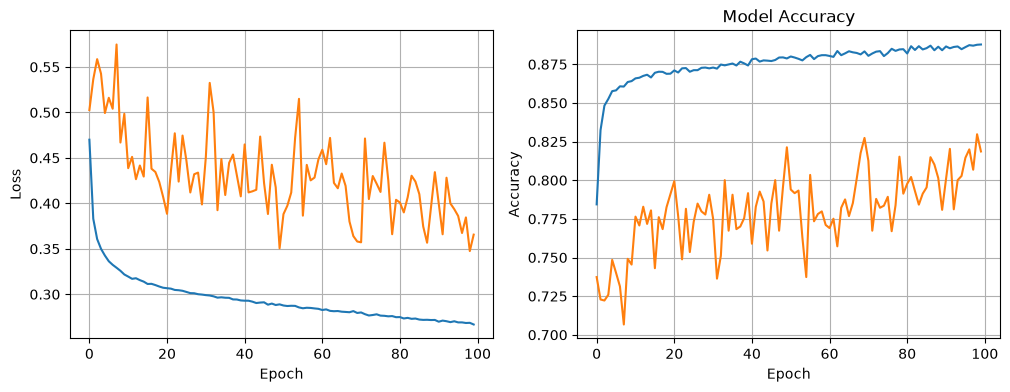

In [64]:
plot_history(history)

### Parameterizing the model as a function

The earlier cells hardcoded every choice — 32 nodes, `lr=0.001`, `epochs=100`, etc. — directly into the model definition, so trying a different setting meant hand-editing that cell each time. `train_model` wraps the same build → compile → fit steps in a function so those choices become **arguments** instead, letting a later section loop over many combinations automatically.

- `X_train, y_train` — the scaled, oversampled training data (from `scale_dataset` earlier) the network learns from.
- `num_nodes` — width of the hidden layers (how many neurons each `Dense` layer gets). More nodes = more capacity to fit complex patterns, at the cost of more parameters and higher overfitting risk.
- `dropout_prob` — the fraction of neurons randomly zeroed out on each training step by the `Dropout` layer. This forces the network to not over-rely on any single neuron, which helps fight overfitting — `0.5` means half the neurons in that layer are dropped per step.
- `lr` — the learning rate passed to the `Adam` optimizer: how large a step each weight takes during a gradient descent update. Too high and training can overshoot/diverge; too low and training is slow to converge.
- `batch_size` — how many training examples are processed together before each weight update.
- `epochs` — how many full passes over the training data to run.

**Note:** as written, the function body isn't using its own parameters yet — `64`, `0.5`, `32`, and the compile settings are still hardcoded, and `nn_model` is built/compiled as a bare module-level assignment rather than inside the function. The `def` line also has no indented body under it (the next line is blank, then everything is dedented back to column 0), which will raise an `IndentationError` as written. To make the sweep below actually vary anything, the body needs to be indented under `def`, route `num_nodes` / `dropout_prob` / `lr` into the layer and optimizer calls, and `return` the trained model.

**What is hyperparameter tuning, in three lines:** hyperparameters (like `num_nodes`, `dropout_prob`, `lr`, `batch_size`) are settings chosen *before* training that the model itself never learns — unlike weights, gradient descent can't optimize them directly. Hyperparameter tuning means trying different combinations of these settings, training a model for each, and comparing performance (typically on the validation set, `X_valid`/`y_valid`) to see which combination generalizes best. It's a search problem layered on top of the normal training loop — each combination requires training an entirely new model from scratch to evaluate.

In [65]:
def train_model(X_train, y_train, num_nodes, dropout_prob, lr, batch_size, epochs):
    
    nn_model = tf.keras.Sequential([
        tf.keras.layers.Dense(num_nodes, activation='relu', input_shape=(10,)),
        tf.keras.layers.Dropout(dropout_prob),
        tf.keras.layers.Dense(num_nodes, activation='relu'),
        tf.keras.layers.Dropout(dropout_prob),
        tf.keras.layers.Dense(1, activation='sigmoid')]
    )

    nn_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                    loss = 'binary_crossentropy', metrics=['accuracy'])

    history = nn_model.fit(X_train, y_train, validation_split=0.2, batch_size=batch_size, epochs=epochs, verbose=1)

    return nn_model, history

16 nodes, dropout: 0, lr: 0.01, batch_size: 32
Epoch 1/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 543us/step - accuracy: 0.8232 - loss: 0.3973 - val_accuracy: 0.7593 - val_loss: 0.4508
Epoch 2/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 329us/step - accuracy: 0.8472 - loss: 0.3537 - val_accuracy: 0.7030 - val_loss: 0.5572
Epoch 3/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 371us/step - accuracy: 0.8574 - loss: 0.3406 - val_accuracy: 0.7525 - val_loss: 0.4632
Epoch 4/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 338us/step - accuracy: 0.8591 - loss: 0.3343 - val_accuracy: 0.7967 - val_loss: 0.4155
Epoch 5/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 336us/step - accuracy: 0.8586 - loss: 0.3319 - val_accuracy: 0.7276 - val_loss: 0.5045
Epoch 6/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 353us/step - accuracy: 0.8637 - loss: 0.3249 - val_accuracy: 0.7529 - val_loss: 0.4987
Epoch 7/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 403us/step - accuracy: 0.8630 - loss: 0.3237 - val_accuracy: 0.7539 - val_loss: 0.4484
Epoch 8/100
371/371 ━━━━━━━━━━━━━━━━

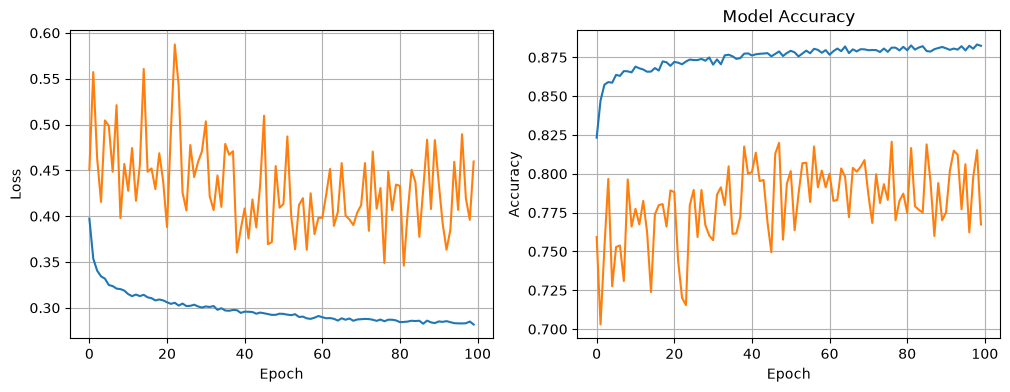

16 nodes, dropout: 0, lr: 0.01, batch_size: 64
Epoch 1/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 1s 755us/step - accuracy: 0.8151 - loss: 0.4149 - val_accuracy: 0.6527 - val_loss: 0.6342
Epoch 2/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 387us/step - accuracy: 0.8468 - loss: 0.3640 - val_accuracy: 0.7576 - val_loss: 0.4426
Epoch 3/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 381us/step - accuracy: 0.8553 - loss: 0.3470 - val_accuracy: 0.7893 - val_loss: 0.3916
Epoch 4/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 379us/step - accuracy: 0.8529 - loss: 0.3465 - val_accuracy: 0.7296 - val_loss: 0.4850
Epoch 5/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 383us/step - accuracy: 0.8595 - loss: 0.3356 - val_accuracy: 0.7454 - val_loss: 0.4946
Epoch 6/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 393us/step - accuracy: 0.8612 - loss: 0.3298 - val_accuracy: 0.6929 - val_loss: 0.5636
Epoch 7/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 390us/step - accuracy: 0.8625 - loss: 0.3284 - val_accuracy: 0.7728 - val_loss: 0.4569
Epoch 8/100
186/186 ━━━━━━━━━━━━━━━━

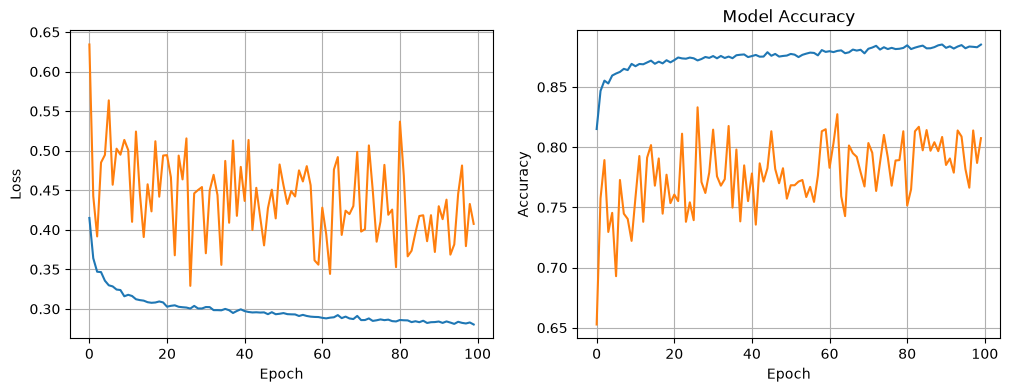

16 nodes, dropout: 0, lr: 0.01, batch_size: 128
Epoch 1/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7975 - loss: 0.4372 - val_accuracy: 0.6972 - val_loss: 0.5814
Epoch 2/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 487us/step - accuracy: 0.8430 - loss: 0.3663 - val_accuracy: 0.7886 - val_loss: 0.4375
Epoch 3/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 490us/step - accuracy: 0.8501 - loss: 0.3538 - val_accuracy: 0.7478 - val_loss: 0.5185
Epoch 4/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 531us/step - accuracy: 0.8537 - loss: 0.3497 - val_accuracy: 0.7519 - val_loss: 0.4852
Epoch 5/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 536us/step - accuracy: 0.8554 - loss: 0.3378 - val_accuracy: 0.7451 - val_loss: 0.4922
Epoch 6/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 481us/step - accuracy: 0.8587 - loss: 0.3318 - val_accuracy: 0.7532 - val_loss: 0.4953
Epoch 7/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 594us/step - accuracy: 0.8622 - loss: 0.3284 - val_accuracy: 0.8115 - val_loss: 0.3668
Epoch 8/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 635us/ste

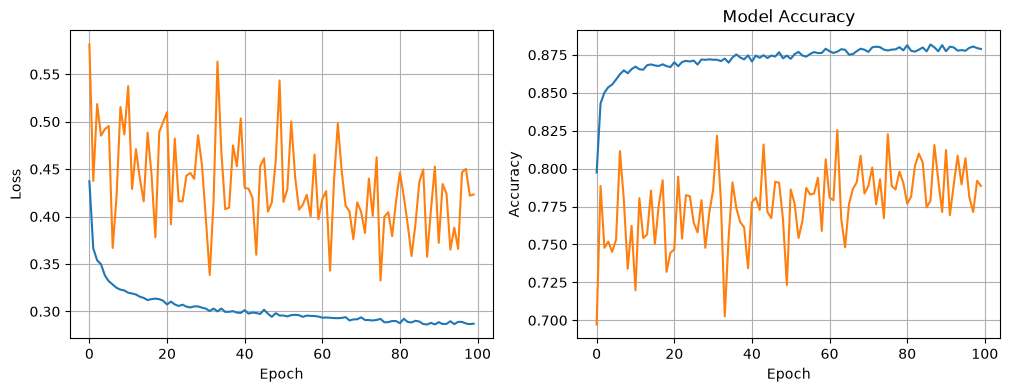

16 nodes, dropout: 0, lr: 0.0005, batch_size: 32
Epoch 1/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 554us/step - accuracy: 0.7338 - loss: 0.5535 - val_accuracy: 0.5944 - val_loss: 0.6547
Epoch 2/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 353us/step - accuracy: 0.7948 - loss: 0.4439 - val_accuracy: 0.6561 - val_loss: 0.5948
Epoch 3/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 353us/step - accuracy: 0.8098 - loss: 0.4183 - val_accuracy: 0.6770 - val_loss: 0.5648
Epoch 4/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 346us/step - accuracy: 0.8205 - loss: 0.4025 - val_accuracy: 0.6935 - val_loss: 0.5548
Epoch 5/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 361us/step - accuracy: 0.8318 - loss: 0.3884 - val_accuracy: 0.6986 - val_loss: 0.5454
Epoch 6/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 405us/step - accuracy: 0.8397 - loss: 0.3758 - val_accuracy: 0.7036 - val_loss: 0.5387
Epoch 7/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 342us/step - accuracy: 0.8458 - loss: 0.3654 - val_accuracy: 0.7235 - val_loss: 0.5212
Epoch 8/100
371/371 ━━━━━━━━━━━━━━

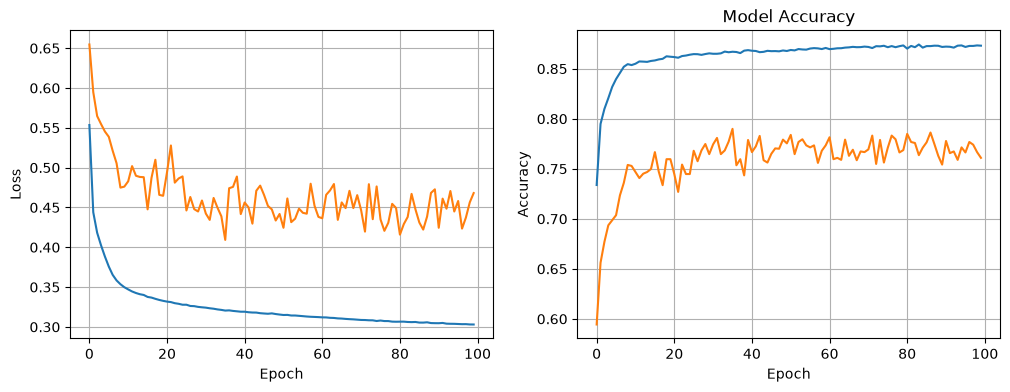

16 nodes, dropout: 0, lr: 0.0005, batch_size: 64
Epoch 1/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 1s 781us/step - accuracy: 0.6961 - loss: 0.6060 - val_accuracy: 0.5630 - val_loss: 0.6878
Epoch 2/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 421us/step - accuracy: 0.7907 - loss: 0.4753 - val_accuracy: 0.6194 - val_loss: 0.6479
Epoch 3/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 442us/step - accuracy: 0.8063 - loss: 0.4257 - val_accuracy: 0.6689 - val_loss: 0.5850
Epoch 4/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 385us/step - accuracy: 0.8184 - loss: 0.4056 - val_accuracy: 0.6753 - val_loss: 0.5750
Epoch 5/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 407us/step - accuracy: 0.8285 - loss: 0.3934 - val_accuracy: 0.6976 - val_loss: 0.5505
Epoch 6/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 414us/step - accuracy: 0.8318 - loss: 0.3850 - val_accuracy: 0.6814 - val_loss: 0.5721
Epoch 7/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 411us/step - accuracy: 0.8363 - loss: 0.3785 - val_accuracy: 0.7168 - val_loss: 0.5315
Epoch 8/100
186/186 ━━━━━━━━━━━━━━

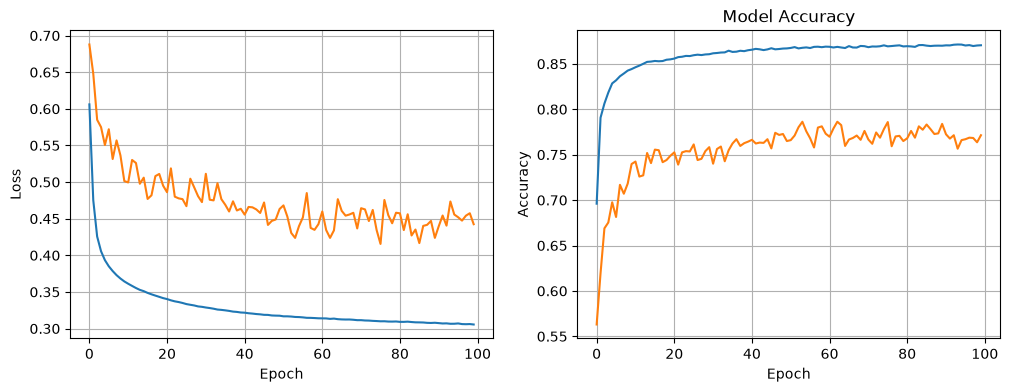

16 nodes, dropout: 0, lr: 0.0005, batch_size: 128
Epoch 1/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4746 - loss: 0.7098 - val_accuracy: 0.6578 - val_loss: 0.5896
Epoch 2/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 521us/step - accuracy: 0.7226 - loss: 0.6154 - val_accuracy: 0.5212 - val_loss: 0.6339
Epoch 3/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 510us/step - accuracy: 0.7695 - loss: 0.5325 - val_accuracy: 0.5496 - val_loss: 0.6258
Epoch 4/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 508us/step - accuracy: 0.7865 - loss: 0.4740 - val_accuracy: 0.6005 - val_loss: 0.6069
Epoch 5/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 488us/step - accuracy: 0.7999 - loss: 0.4424 - val_accuracy: 0.6194 - val_loss: 0.6084
Epoch 6/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 502us/step - accuracy: 0.8074 - loss: 0.4250 - val_accuracy: 0.6514 - val_loss: 0.5902
Epoch 7/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 506us/step - accuracy: 0.8154 - loss: 0.4132 - val_accuracy: 0.6753 - val_loss: 0.5657
Epoch 8/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 489us/s

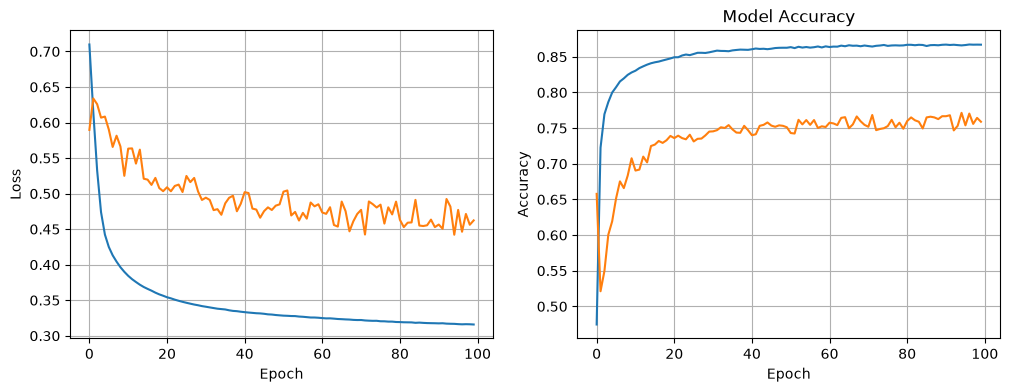

16 nodes, dropout: 0, lr: 0.001, batch_size: 32
Epoch 1/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 533us/step - accuracy: 0.7761 - loss: 0.4921 - val_accuracy: 0.6392 - val_loss: 0.6000
Epoch 2/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 340us/step - accuracy: 0.8282 - loss: 0.3907 - val_accuracy: 0.7141 - val_loss: 0.5320
Epoch 3/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 338us/step - accuracy: 0.8399 - loss: 0.3717 - val_accuracy: 0.7495 - val_loss: 0.4995
Epoch 4/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 338us/step - accuracy: 0.8519 - loss: 0.3603 - val_accuracy: 0.7488 - val_loss: 0.5110
Epoch 5/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 338us/step - accuracy: 0.8542 - loss: 0.3541 - val_accuracy: 0.7428 - val_loss: 0.5141
Epoch 6/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 348us/step - accuracy: 0.8559 - loss: 0.3484 - val_accuracy: 0.7714 - val_loss: 0.4652
Epoch 7/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 345us/step - accuracy: 0.8570 - loss: 0.3451 - val_accuracy: 0.7572 - val_loss: 0.4864
Epoch 8/100
371/371 ━━━━━━━━━━━━━━━

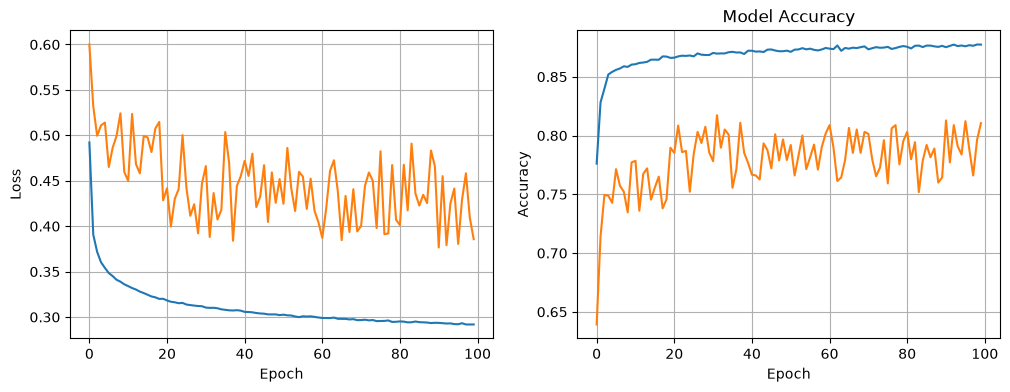

16 nodes, dropout: 0, lr: 0.001, batch_size: 64
Epoch 1/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 1s 780us/step - accuracy: 0.6966 - loss: 0.5816 - val_accuracy: 0.5614 - val_loss: 0.6722
Epoch 2/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 402us/step - accuracy: 0.7959 - loss: 0.4418 - val_accuracy: 0.6379 - val_loss: 0.6124
Epoch 3/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 384us/step - accuracy: 0.8126 - loss: 0.4118 - val_accuracy: 0.6258 - val_loss: 0.6377
Epoch 4/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 378us/step - accuracy: 0.8247 - loss: 0.3931 - val_accuracy: 0.7127 - val_loss: 0.5194
Epoch 5/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 379us/step - accuracy: 0.8367 - loss: 0.3773 - val_accuracy: 0.7293 - val_loss: 0.5037
Epoch 6/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 380us/step - accuracy: 0.8428 - loss: 0.3664 - val_accuracy: 0.7428 - val_loss: 0.4963
Epoch 7/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 384us/step - accuracy: 0.8505 - loss: 0.3576 - val_accuracy: 0.7569 - val_loss: 0.4704
Epoch 8/100
186/186 ━━━━━━━━━━━━━━━

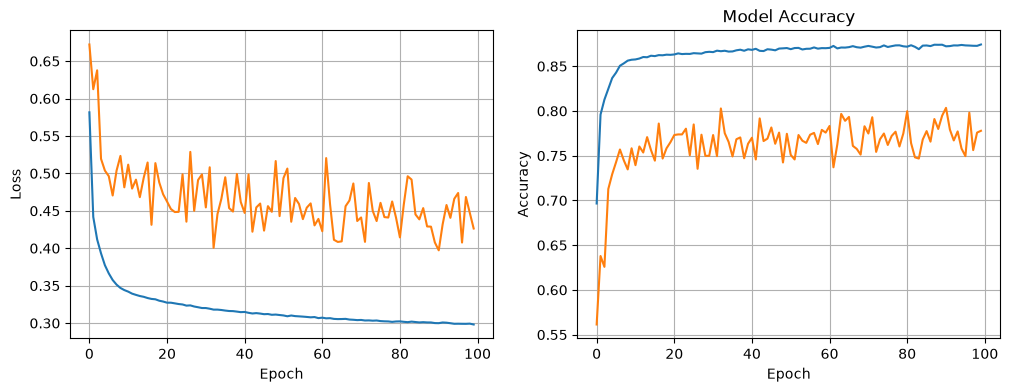

16 nodes, dropout: 0, lr: 0.001, batch_size: 128
Epoch 1/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6962 - loss: 0.6044 - val_accuracy: 0.4697 - val_loss: 0.7101
Epoch 2/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 492us/step - accuracy: 0.7789 - loss: 0.4787 - val_accuracy: 0.6339 - val_loss: 0.6224
Epoch 3/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 491us/step - accuracy: 0.7989 - loss: 0.4336 - val_accuracy: 0.6679 - val_loss: 0.5864
Epoch 4/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 560us/step - accuracy: 0.8114 - loss: 0.4145 - val_accuracy: 0.6858 - val_loss: 0.5643
Epoch 5/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 542us/step - accuracy: 0.8176 - loss: 0.4018 - val_accuracy: 0.7040 - val_loss: 0.5483
Epoch 6/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 528us/step - accuracy: 0.8264 - loss: 0.3924 - val_accuracy: 0.7165 - val_loss: 0.5320
Epoch 7/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 543us/step - accuracy: 0.8344 - loss: 0.3841 - val_accuracy: 0.7336 - val_loss: 0.5176
Epoch 8/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 547us/st

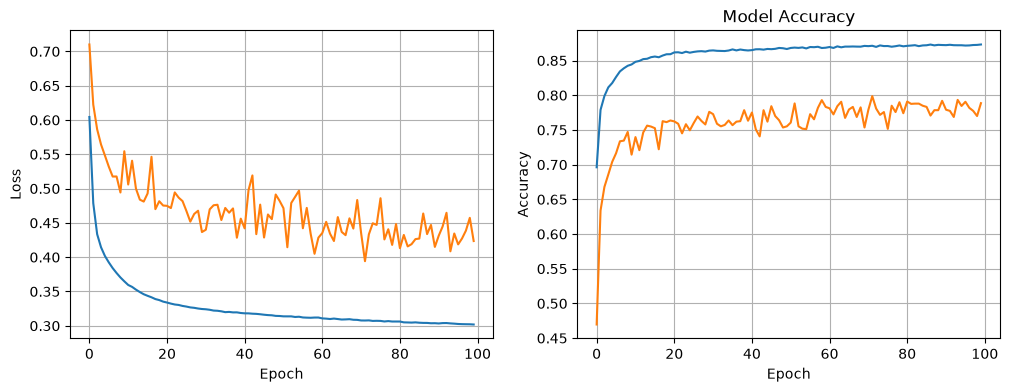

16 nodes, dropout: 0.2, lr: 0.01, batch_size: 32
Epoch 1/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 551us/step - accuracy: 0.7967 - loss: 0.4509 - val_accuracy: 0.6460 - val_loss: 0.6403
Epoch 2/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 357us/step - accuracy: 0.8250 - loss: 0.4082 - val_accuracy: 0.6767 - val_loss: 0.5563
Epoch 3/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 380us/step - accuracy: 0.8342 - loss: 0.3899 - val_accuracy: 0.6696 - val_loss: 0.6253
Epoch 4/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 346us/step - accuracy: 0.8378 - loss: 0.3836 - val_accuracy: 0.7397 - val_loss: 0.4777
Epoch 5/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 359us/step - accuracy: 0.8412 - loss: 0.3742 - val_accuracy: 0.7296 - val_loss: 0.5149
Epoch 6/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 351us/step - accuracy: 0.8440 - loss: 0.3720 - val_accuracy: 0.7208 - val_loss: 0.4930
Epoch 7/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 352us/step - accuracy: 0.8460 - loss: 0.3699 - val_accuracy: 0.6693 - val_loss: 0.5771
Epoch 8/100
371/371 ━━━━━━━━━━━━━━

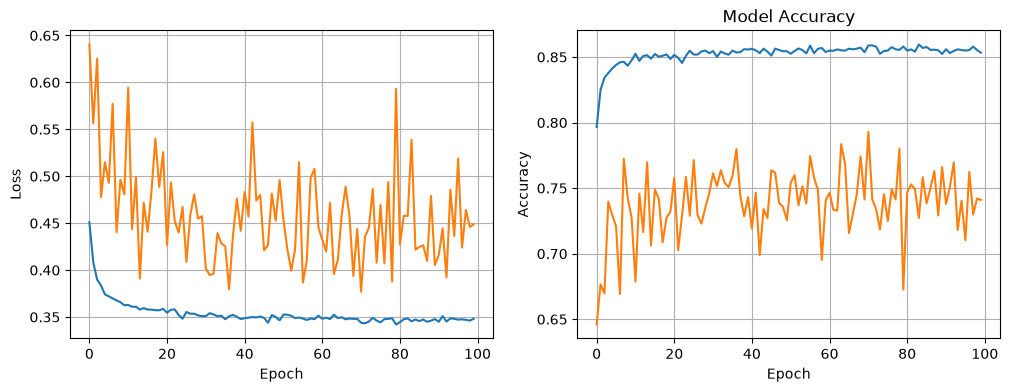

16 nodes, dropout: 0.2, lr: 0.01, batch_size: 64
Epoch 1/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 1s 778us/step - accuracy: 0.7851 - loss: 0.4654 - val_accuracy: 0.7330 - val_loss: 0.5234
Epoch 2/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 461us/step - accuracy: 0.8232 - loss: 0.4132 - val_accuracy: 0.7579 - val_loss: 0.5231
Epoch 3/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 460us/step - accuracy: 0.8315 - loss: 0.3921 - val_accuracy: 0.6969 - val_loss: 0.4899
Epoch 4/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 403us/step - accuracy: 0.8390 - loss: 0.3728 - val_accuracy: 0.7363 - val_loss: 0.5069
Epoch 5/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 385us/step - accuracy: 0.8410 - loss: 0.3705 - val_accuracy: 0.7100 - val_loss: 0.5055
Epoch 6/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 391us/step - accuracy: 0.8425 - loss: 0.3727 - val_accuracy: 0.7937 - val_loss: 0.3790
Epoch 7/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 398us/step - accuracy: 0.8439 - loss: 0.3653 - val_accuracy: 0.7235 - val_loss: 0.5215
Epoch 8/100
186/186 ━━━━━━━━━━━━━━

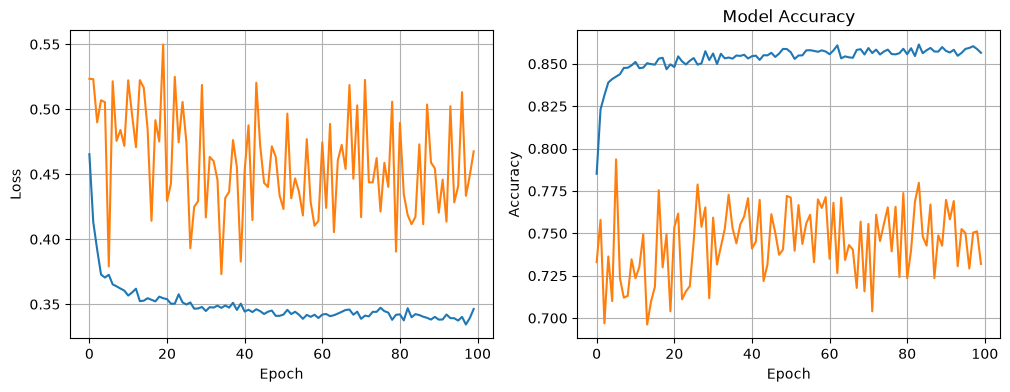

16 nodes, dropout: 0.2, lr: 0.01, batch_size: 128
Epoch 1/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7643 - loss: 0.4910 - val_accuracy: 0.6541 - val_loss: 0.6129
Epoch 2/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 546us/step - accuracy: 0.8179 - loss: 0.4162 - val_accuracy: 0.6966 - val_loss: 0.6039
Epoch 3/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 503us/step - accuracy: 0.8318 - loss: 0.3939 - val_accuracy: 0.7434 - val_loss: 0.5208
Epoch 4/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 497us/step - accuracy: 0.8375 - loss: 0.3852 - val_accuracy: 0.7269 - val_loss: 0.4871
Epoch 5/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 493us/step - accuracy: 0.8388 - loss: 0.3779 - val_accuracy: 0.7583 - val_loss: 0.4300
Epoch 6/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 494us/step - accuracy: 0.8423 - loss: 0.3705 - val_accuracy: 0.7225 - val_loss: 0.4966
Epoch 7/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 497us/step - accuracy: 0.8442 - loss: 0.3639 - val_accuracy: 0.7205 - val_loss: 0.5180
Epoch 8/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 499us/s

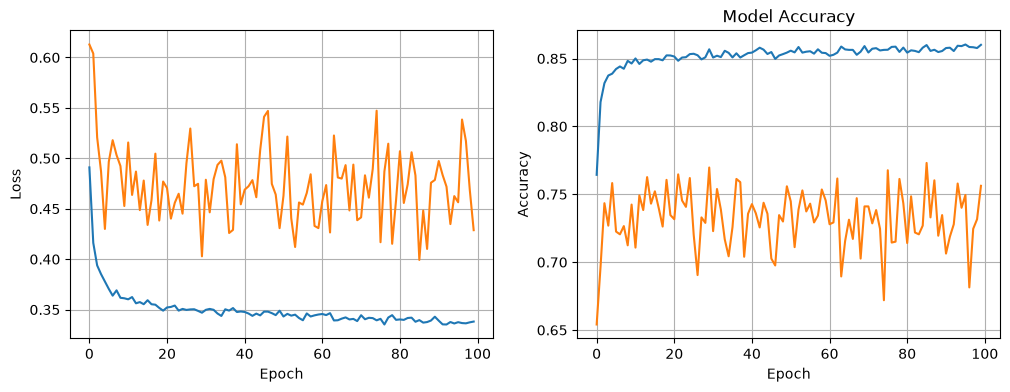

16 nodes, dropout: 0.2, lr: 0.0005, batch_size: 32
Epoch 1/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 562us/step - accuracy: 0.6551 - loss: 0.6237 - val_accuracy: 0.5459 - val_loss: 0.6931
Epoch 2/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 354us/step - accuracy: 0.7640 - loss: 0.5070 - val_accuracy: 0.6032 - val_loss: 0.6426
Epoch 3/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 350us/step - accuracy: 0.7691 - loss: 0.4828 - val_accuracy: 0.5981 - val_loss: 0.6439
Epoch 4/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 382us/step - accuracy: 0.7805 - loss: 0.4649 - val_accuracy: 0.6028 - val_loss: 0.6098
Epoch 5/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 345us/step - accuracy: 0.7835 - loss: 0.4573 - val_accuracy: 0.6086 - val_loss: 0.6192
Epoch 6/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 355us/step - accuracy: 0.7892 - loss: 0.4510 - val_accuracy: 0.6092 - val_loss: 0.6198
Epoch 7/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 350us/step - accuracy: 0.7936 - loss: 0.4436 - val_accuracy: 0.6214 - val_loss: 0.6032
Epoch 8/100
371/371 ━━━━━━━━━━━━

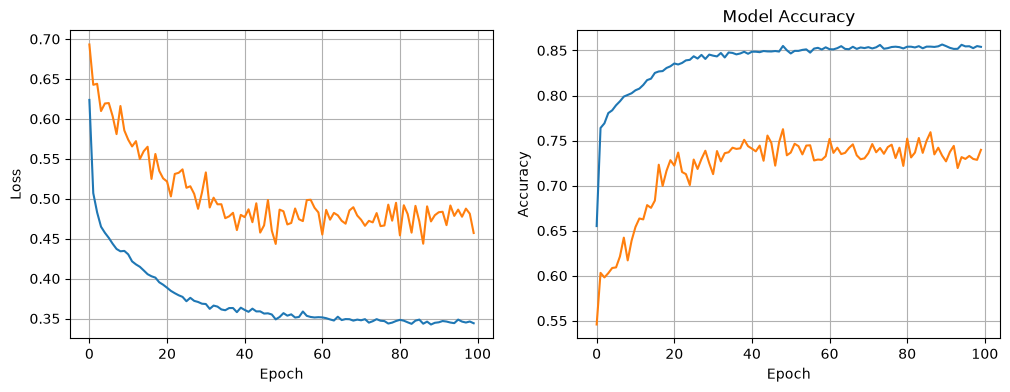

16 nodes, dropout: 0.2, lr: 0.0005, batch_size: 64
Epoch 1/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 1s 785us/step - accuracy: 0.6031 - loss: 0.6492 - val_accuracy: 0.2411 - val_loss: 0.8003
Epoch 2/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 410us/step - accuracy: 0.7102 - loss: 0.5591 - val_accuracy: 0.4053 - val_loss: 0.7624
Epoch 3/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 404us/step - accuracy: 0.7532 - loss: 0.5099 - val_accuracy: 0.5634 - val_loss: 0.6991
Epoch 4/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 418us/step - accuracy: 0.7817 - loss: 0.4783 - val_accuracy: 0.6163 - val_loss: 0.6472
Epoch 5/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 408us/step - accuracy: 0.7925 - loss: 0.4559 - val_accuracy: 0.6389 - val_loss: 0.6129
Epoch 6/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 404us/step - accuracy: 0.8003 - loss: 0.4472 - val_accuracy: 0.6416 - val_loss: 0.6068
Epoch 7/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 393us/step - accuracy: 0.8066 - loss: 0.4399 - val_accuracy: 0.6369 - val_loss: 0.6056
Epoch 8/100
186/186 ━━━━━━━━━━━━

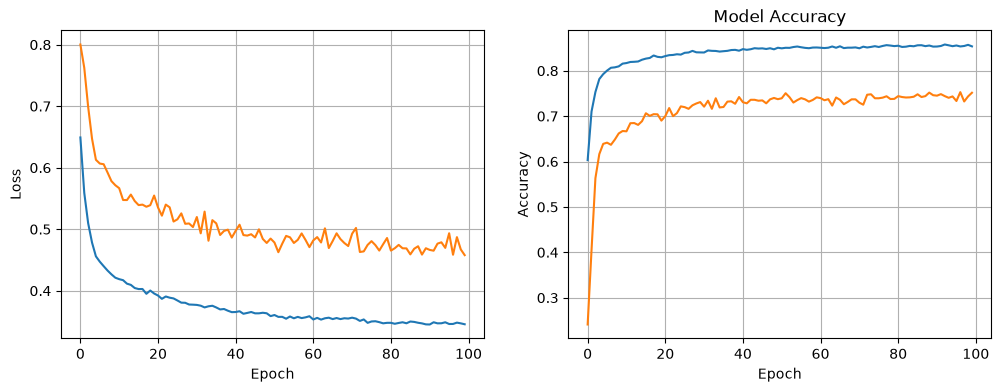

16 nodes, dropout: 0.2, lr: 0.0005, batch_size: 128
Epoch 1/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6166 - loss: 0.6593 - val_accuracy: 0.3523 - val_loss: 0.7343
Epoch 2/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 568us/step - accuracy: 0.6995 - loss: 0.5833 - val_accuracy: 0.4393 - val_loss: 0.6996
Epoch 3/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 569us/step - accuracy: 0.7320 - loss: 0.5299 - val_accuracy: 0.5337 - val_loss: 0.6676
Epoch 4/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 521us/step - accuracy: 0.7583 - loss: 0.4965 - val_accuracy: 0.5937 - val_loss: 0.6390
Epoch 5/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 600us/step - accuracy: 0.7658 - loss: 0.4835 - val_accuracy: 0.6170 - val_loss: 0.6277
Epoch 6/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 609us/step - accuracy: 0.7784 - loss: 0.4645 - val_accuracy: 0.6382 - val_loss: 0.6018
Epoch 7/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 572us/step - accuracy: 0.7884 - loss: 0.4567 - val_accuracy: 0.6490 - val_loss: 0.5975
Epoch 8/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 578us

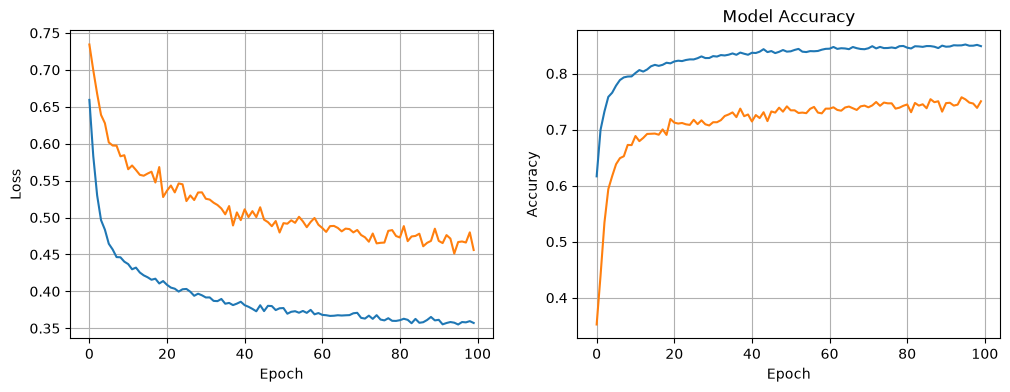

16 nodes, dropout: 0.2, lr: 0.001, batch_size: 32
Epoch 1/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 553us/step - accuracy: 0.7326 - loss: 0.5463 - val_accuracy: 0.6355 - val_loss: 0.6174
Epoch 2/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 349us/step - accuracy: 0.7925 - loss: 0.4598 - val_accuracy: 0.6467 - val_loss: 0.6214
Epoch 3/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 350us/step - accuracy: 0.8027 - loss: 0.4413 - val_accuracy: 0.6686 - val_loss: 0.5714
Epoch 4/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 349us/step - accuracy: 0.8058 - loss: 0.4302 - val_accuracy: 0.6689 - val_loss: 0.5710
Epoch 5/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 349us/step - accuracy: 0.8108 - loss: 0.4242 - val_accuracy: 0.6679 - val_loss: 0.5619
Epoch 6/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 349us/step - accuracy: 0.8163 - loss: 0.4113 - val_accuracy: 0.7218 - val_loss: 0.5121
Epoch 7/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 348us/step - accuracy: 0.8259 - loss: 0.4047 - val_accuracy: 0.7272 - val_loss: 0.5161
Epoch 8/100
371/371 ━━━━━━━━━━━━━

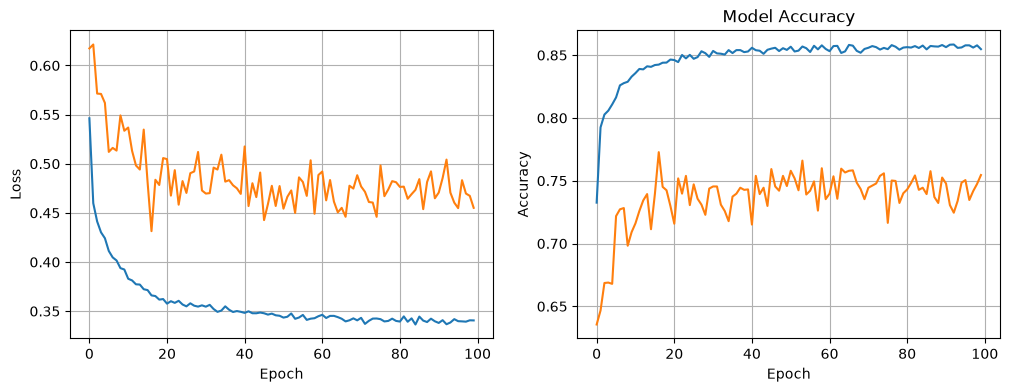

16 nodes, dropout: 0.2, lr: 0.001, batch_size: 64
Epoch 1/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 1s 786us/step - accuracy: 0.6438 - loss: 0.6534 - val_accuracy: 0.4919 - val_loss: 0.8013
Epoch 2/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 413us/step - accuracy: 0.7676 - loss: 0.4986 - val_accuracy: 0.6473 - val_loss: 0.6544
Epoch 3/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 403us/step - accuracy: 0.7961 - loss: 0.4509 - val_accuracy: 0.6743 - val_loss: 0.5922
Epoch 4/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 403us/step - accuracy: 0.8022 - loss: 0.4417 - val_accuracy: 0.6396 - val_loss: 0.6343
Epoch 5/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 400us/step - accuracy: 0.8093 - loss: 0.4321 - val_accuracy: 0.7006 - val_loss: 0.5411
Epoch 6/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 419us/step - accuracy: 0.8141 - loss: 0.4251 - val_accuracy: 0.6649 - val_loss: 0.5961
Epoch 7/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 388us/step - accuracy: 0.8188 - loss: 0.4142 - val_accuracy: 0.6962 - val_loss: 0.5503
Epoch 8/100
186/186 ━━━━━━━━━━━━━

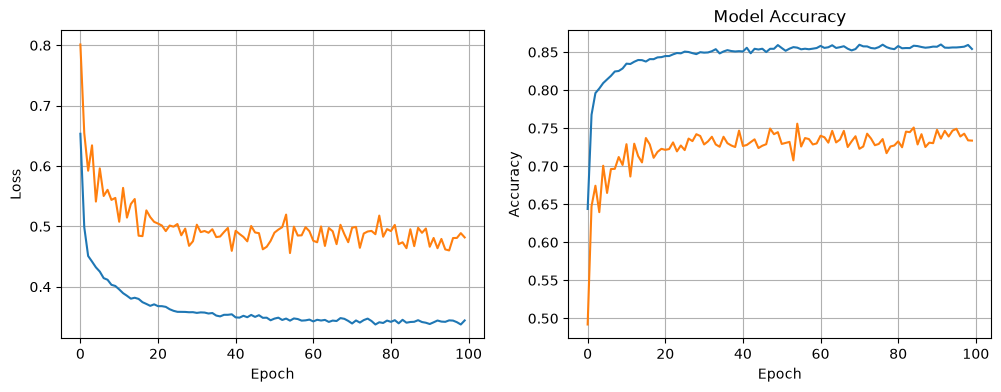

16 nodes, dropout: 0.2, lr: 0.001, batch_size: 128
Epoch 1/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6642 - loss: 0.6271 - val_accuracy: 0.5155 - val_loss: 0.6787
Epoch 2/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 501us/step - accuracy: 0.7534 - loss: 0.5199 - val_accuracy: 0.5792 - val_loss: 0.6453
Epoch 3/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 495us/step - accuracy: 0.7739 - loss: 0.4811 - val_accuracy: 0.5897 - val_loss: 0.6604
Epoch 4/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 516us/step - accuracy: 0.7850 - loss: 0.4575 - val_accuracy: 0.6392 - val_loss: 0.5982
Epoch 5/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 511us/step - accuracy: 0.7928 - loss: 0.4540 - val_accuracy: 0.6460 - val_loss: 0.6030
Epoch 6/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 495us/step - accuracy: 0.8000 - loss: 0.4421 - val_accuracy: 0.6531 - val_loss: 0.6080
Epoch 7/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 504us/step - accuracy: 0.8038 - loss: 0.4363 - val_accuracy: 0.6618 - val_loss: 0.5991
Epoch 8/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 480us/

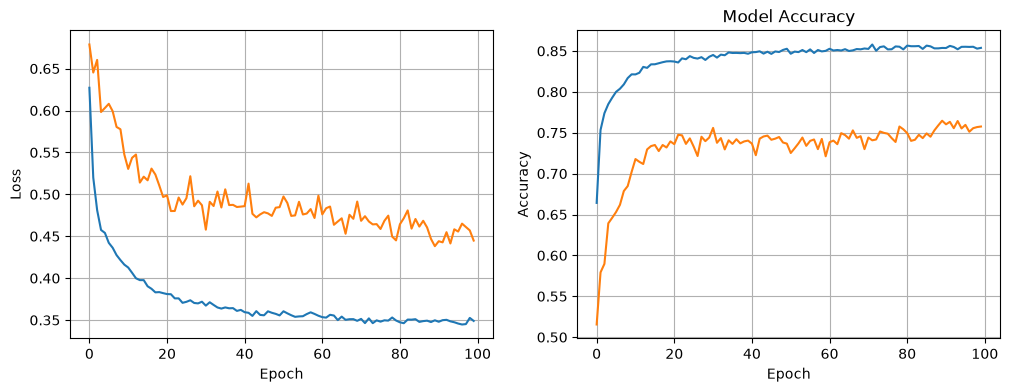

32 nodes, dropout: 0, lr: 0.01, batch_size: 32
Epoch 1/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 545us/step - accuracy: 0.8267 - loss: 0.3939 - val_accuracy: 0.6868 - val_loss: 0.5909
Epoch 2/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 362us/step - accuracy: 0.8519 - loss: 0.3502 - val_accuracy: 0.7168 - val_loss: 0.5271
Epoch 3/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 341us/step - accuracy: 0.8554 - loss: 0.3412 - val_accuracy: 0.7131 - val_loss: 0.5096
Epoch 4/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 352us/step - accuracy: 0.8610 - loss: 0.3344 - val_accuracy: 0.7444 - val_loss: 0.5106
Epoch 5/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 349us/step - accuracy: 0.8629 - loss: 0.3280 - val_accuracy: 0.7310 - val_loss: 0.5199
Epoch 6/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 346us/step - accuracy: 0.8648 - loss: 0.3249 - val_accuracy: 0.7485 - val_loss: 0.4811
Epoch 7/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 342us/step - accuracy: 0.8621 - loss: 0.3245 - val_accuracy: 0.7893 - val_loss: 0.4146
Epoch 8/100
371/371 ━━━━━━━━━━━━━━━━

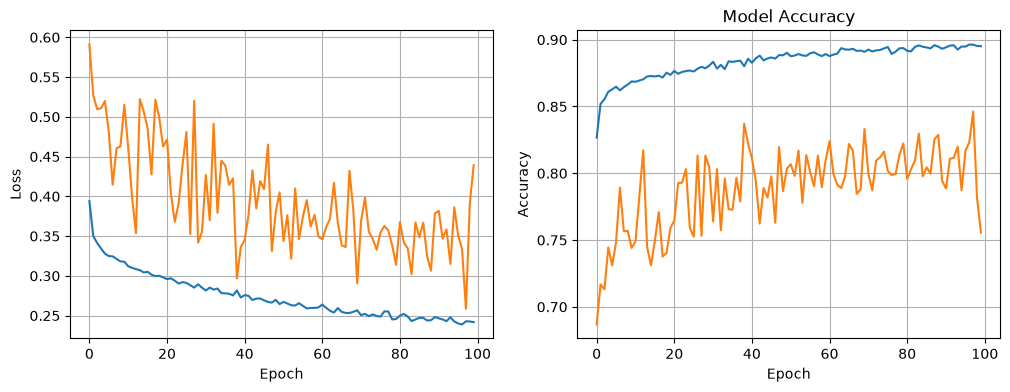

32 nodes, dropout: 0, lr: 0.01, batch_size: 64
Epoch 1/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 1s 784us/step - accuracy: 0.8200 - loss: 0.4039 - val_accuracy: 0.7478 - val_loss: 0.4796
Epoch 2/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 400us/step - accuracy: 0.8499 - loss: 0.3512 - val_accuracy: 0.7313 - val_loss: 0.5480
Epoch 3/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 385us/step - accuracy: 0.8577 - loss: 0.3384 - val_accuracy: 0.7862 - val_loss: 0.4136
Epoch 4/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 386us/step - accuracy: 0.8576 - loss: 0.3351 - val_accuracy: 0.7117 - val_loss: 0.5373
Epoch 5/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 405us/step - accuracy: 0.8608 - loss: 0.3295 - val_accuracy: 0.7680 - val_loss: 0.4480
Epoch 6/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 405us/step - accuracy: 0.8613 - loss: 0.3255 - val_accuracy: 0.6760 - val_loss: 0.5978
Epoch 7/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 398us/step - accuracy: 0.8641 - loss: 0.3206 - val_accuracy: 0.7259 - val_loss: 0.5774
Epoch 8/100
186/186 ━━━━━━━━━━━━━━━━

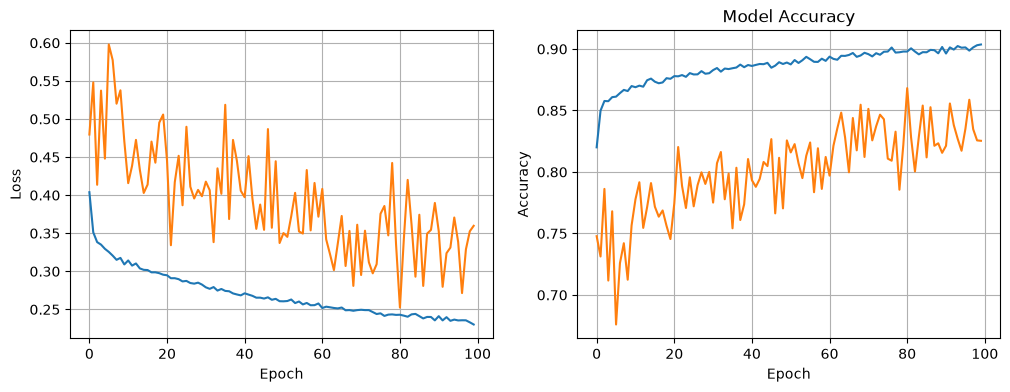

32 nodes, dropout: 0, lr: 0.01, batch_size: 128
Epoch 1/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8104 - loss: 0.4152 - val_accuracy: 0.7165 - val_loss: 0.5564
Epoch 2/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 533us/step - accuracy: 0.8479 - loss: 0.3557 - val_accuracy: 0.6854 - val_loss: 0.6266
Epoch 3/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 518us/step - accuracy: 0.8571 - loss: 0.3393 - val_accuracy: 0.7485 - val_loss: 0.4651
Epoch 4/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 493us/step - accuracy: 0.8597 - loss: 0.3312 - val_accuracy: 0.7664 - val_loss: 0.4379
Epoch 5/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 491us/step - accuracy: 0.8626 - loss: 0.3273 - val_accuracy: 0.7606 - val_loss: 0.4541
Epoch 6/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 482us/step - accuracy: 0.8669 - loss: 0.3217 - val_accuracy: 0.7623 - val_loss: 0.4233
Epoch 7/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 493us/step - accuracy: 0.8662 - loss: 0.3189 - val_accuracy: 0.7610 - val_loss: 0.4362
Epoch 8/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 486us/ste

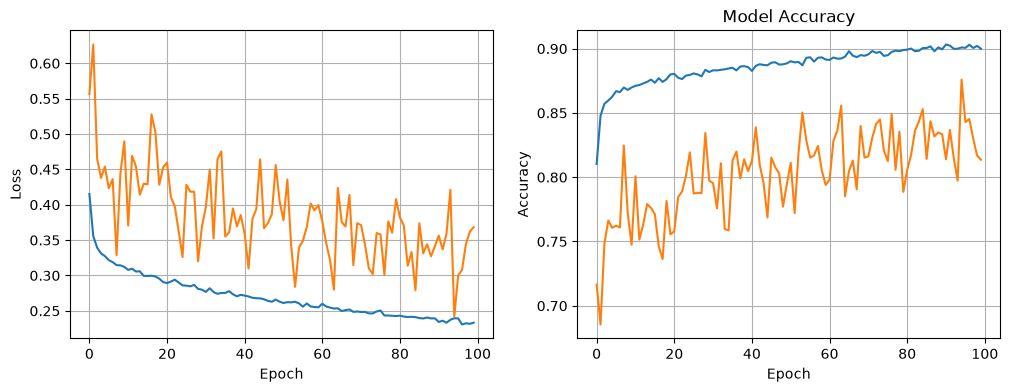

32 nodes, dropout: 0, lr: 0.0005, batch_size: 32
Epoch 1/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 547us/step - accuracy: 0.7621 - loss: 0.5040 - val_accuracy: 0.6689 - val_loss: 0.5926
Epoch 2/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 350us/step - accuracy: 0.8193 - loss: 0.4013 - val_accuracy: 0.7047 - val_loss: 0.5177
Epoch 3/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 353us/step - accuracy: 0.8381 - loss: 0.3769 - val_accuracy: 0.7023 - val_loss: 0.5372
Epoch 4/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 346us/step - accuracy: 0.8486 - loss: 0.3625 - val_accuracy: 0.6642 - val_loss: 0.6182
Epoch 5/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 345us/step - accuracy: 0.8546 - loss: 0.3544 - val_accuracy: 0.7394 - val_loss: 0.5044
Epoch 6/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 343us/step - accuracy: 0.8570 - loss: 0.3483 - val_accuracy: 0.7468 - val_loss: 0.4926
Epoch 7/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 368us/step - accuracy: 0.8578 - loss: 0.3441 - val_accuracy: 0.7283 - val_loss: 0.5418
Epoch 8/100
371/371 ━━━━━━━━━━━━━━

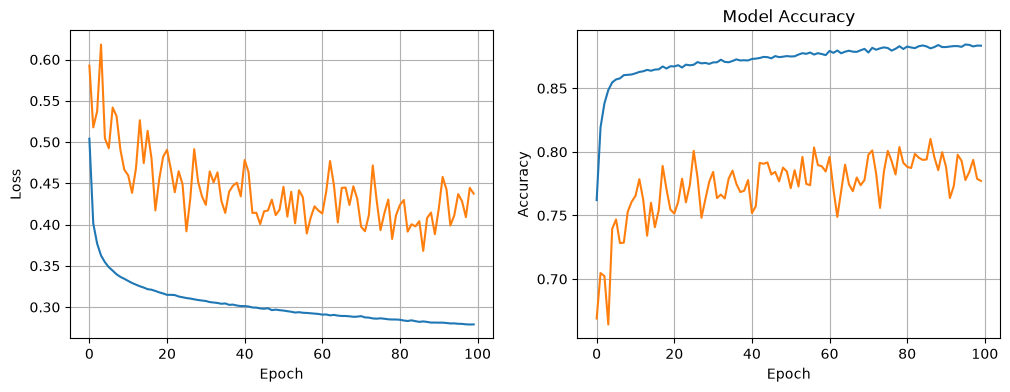

32 nodes, dropout: 0, lr: 0.0005, batch_size: 64
Epoch 1/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 1s 819us/step - accuracy: 0.7123 - loss: 0.5727 - val_accuracy: 0.5715 - val_loss: 0.6974
Epoch 2/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 413us/step - accuracy: 0.8028 - loss: 0.4361 - val_accuracy: 0.6497 - val_loss: 0.6030
Epoch 3/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 393us/step - accuracy: 0.8185 - loss: 0.4066 - val_accuracy: 0.6800 - val_loss: 0.5635
Epoch 4/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 446us/step - accuracy: 0.8268 - loss: 0.3926 - val_accuracy: 0.6871 - val_loss: 0.5542
Epoch 5/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 424us/step - accuracy: 0.8339 - loss: 0.3818 - val_accuracy: 0.7060 - val_loss: 0.5378
Epoch 6/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 419us/step - accuracy: 0.8410 - loss: 0.3734 - val_accuracy: 0.7353 - val_loss: 0.5184
Epoch 7/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 473us/step - accuracy: 0.8431 - loss: 0.3661 - val_accuracy: 0.7158 - val_loss: 0.5570
Epoch 8/100
186/186 ━━━━━━━━━━━━━━

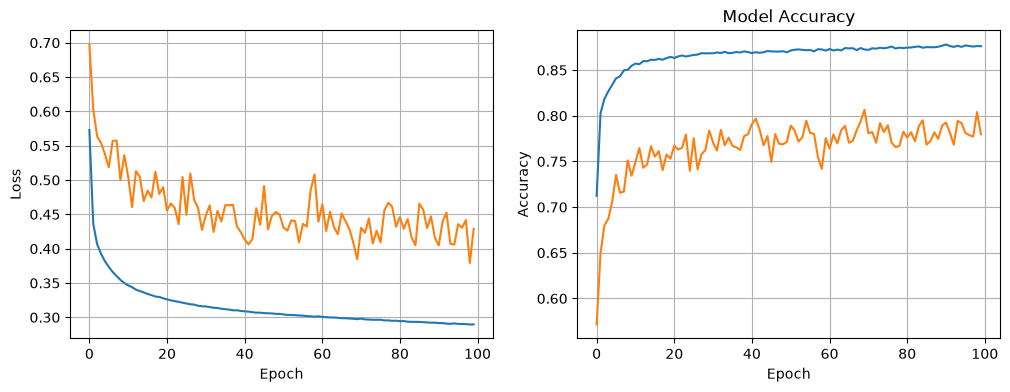

32 nodes, dropout: 0, lr: 0.0005, batch_size: 128
Epoch 1/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6095 - loss: 0.6558 - val_accuracy: 0.4936 - val_loss: 0.6782
Epoch 2/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 552us/step - accuracy: 0.7742 - loss: 0.5272 - val_accuracy: 0.5910 - val_loss: 0.6397
Epoch 3/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 574us/step - accuracy: 0.7909 - loss: 0.4483 - val_accuracy: 0.6227 - val_loss: 0.6344
Epoch 4/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 559us/step - accuracy: 0.8089 - loss: 0.4160 - val_accuracy: 0.6369 - val_loss: 0.6117
Epoch 5/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 561us/step - accuracy: 0.8205 - loss: 0.3990 - val_accuracy: 0.6817 - val_loss: 0.5515
Epoch 6/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 570us/step - accuracy: 0.8300 - loss: 0.3873 - val_accuracy: 0.6915 - val_loss: 0.5428
Epoch 7/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 546us/step - accuracy: 0.8374 - loss: 0.3766 - val_accuracy: 0.7272 - val_loss: 0.4936
Epoch 8/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 567us/s

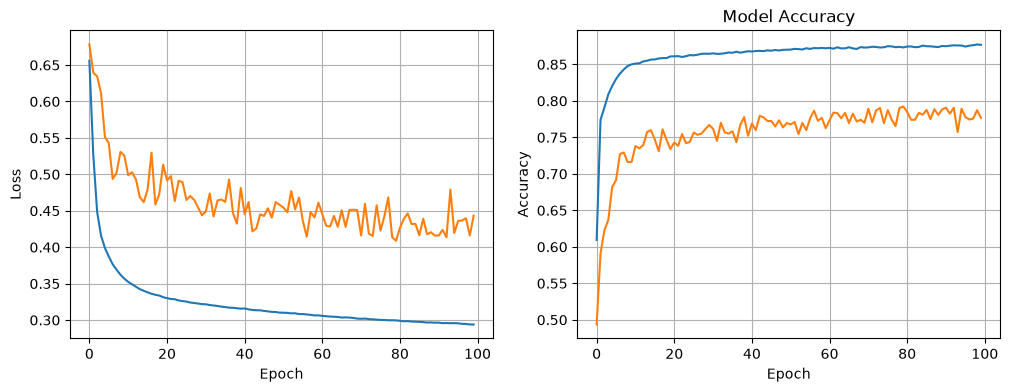

32 nodes, dropout: 0, lr: 0.001, batch_size: 32
Epoch 1/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 545us/step - accuracy: 0.7916 - loss: 0.4587 - val_accuracy: 0.6639 - val_loss: 0.5951
Epoch 2/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 336us/step - accuracy: 0.8325 - loss: 0.3830 - val_accuracy: 0.6639 - val_loss: 0.6165
Epoch 3/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 341us/step - accuracy: 0.8490 - loss: 0.3631 - val_accuracy: 0.7556 - val_loss: 0.4940
Epoch 4/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 336us/step - accuracy: 0.8523 - loss: 0.3519 - val_accuracy: 0.7701 - val_loss: 0.4613
Epoch 5/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 348us/step - accuracy: 0.8562 - loss: 0.3441 - val_accuracy: 0.7610 - val_loss: 0.4838
Epoch 6/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 356us/step - accuracy: 0.8597 - loss: 0.3372 - val_accuracy: 0.7599 - val_loss: 0.4799
Epoch 7/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 342us/step - accuracy: 0.8610 - loss: 0.3337 - val_accuracy: 0.7384 - val_loss: 0.5120
Epoch 8/100
371/371 ━━━━━━━━━━━━━━━

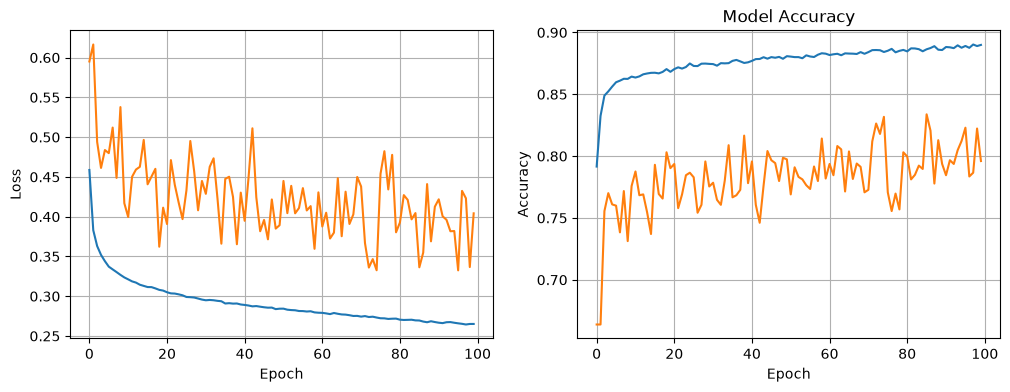

32 nodes, dropout: 0, lr: 0.001, batch_size: 64
Epoch 1/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 1s 798us/step - accuracy: 0.7746 - loss: 0.4824 - val_accuracy: 0.6349 - val_loss: 0.6111
Epoch 2/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 398us/step - accuracy: 0.8203 - loss: 0.3997 - val_accuracy: 0.6885 - val_loss: 0.5448
Epoch 3/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 384us/step - accuracy: 0.8396 - loss: 0.3756 - val_accuracy: 0.7144 - val_loss: 0.5450
Epoch 4/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 415us/step - accuracy: 0.8477 - loss: 0.3620 - val_accuracy: 0.7380 - val_loss: 0.5027
Epoch 5/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 409us/step - accuracy: 0.8538 - loss: 0.3537 - val_accuracy: 0.7812 - val_loss: 0.4362
Epoch 6/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 416us/step - accuracy: 0.8539 - loss: 0.3491 - val_accuracy: 0.7559 - val_loss: 0.4746
Epoch 7/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 419us/step - accuracy: 0.8577 - loss: 0.3444 - val_accuracy: 0.7549 - val_loss: 0.4849
Epoch 8/100
186/186 ━━━━━━━━━━━━━━━

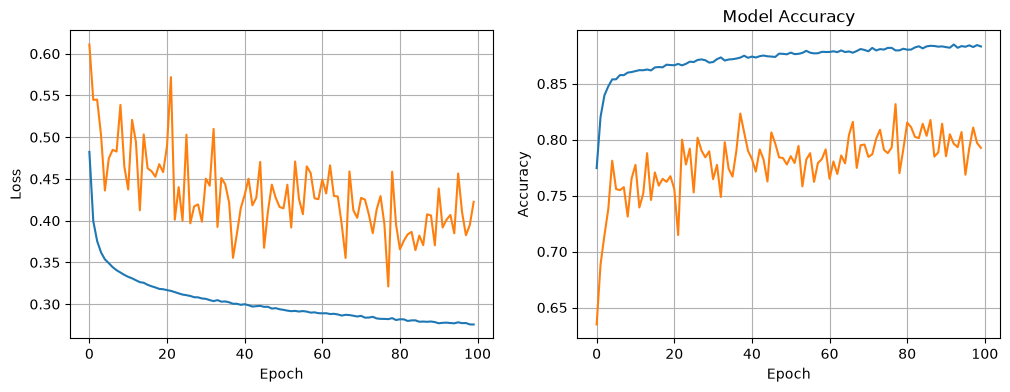

32 nodes, dropout: 0, lr: 0.001, batch_size: 128
Epoch 1/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7307 - loss: 0.5750 - val_accuracy: 0.6001 - val_loss: 0.6405
Epoch 2/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 493us/step - accuracy: 0.8039 - loss: 0.4283 - val_accuracy: 0.6632 - val_loss: 0.5967
Epoch 3/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 513us/step - accuracy: 0.8267 - loss: 0.3909 - val_accuracy: 0.7033 - val_loss: 0.5230
Epoch 4/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 495us/step - accuracy: 0.8375 - loss: 0.3732 - val_accuracy: 0.7087 - val_loss: 0.5375
Epoch 5/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 481us/step - accuracy: 0.8466 - loss: 0.3604 - val_accuracy: 0.7360 - val_loss: 0.4979
Epoch 6/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 479us/step - accuracy: 0.8507 - loss: 0.3525 - val_accuracy: 0.7542 - val_loss: 0.4706
Epoch 7/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 494us/step - accuracy: 0.8530 - loss: 0.3471 - val_accuracy: 0.7458 - val_loss: 0.5080
Epoch 8/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 519us/st

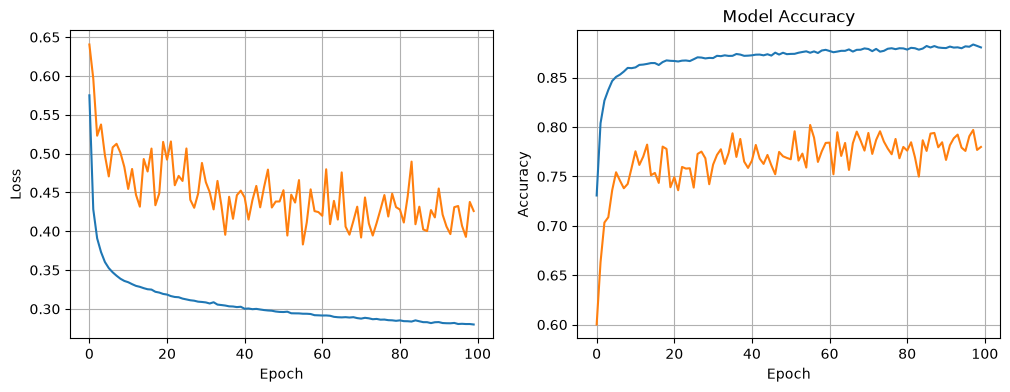

32 nodes, dropout: 0.2, lr: 0.01, batch_size: 32
Epoch 1/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 606us/step - accuracy: 0.8197 - loss: 0.4191 - val_accuracy: 0.7825 - val_loss: 0.4224
Epoch 2/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 395us/step - accuracy: 0.8455 - loss: 0.3712 - val_accuracy: 0.7121 - val_loss: 0.4591
Epoch 3/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 406us/step - accuracy: 0.8446 - loss: 0.3625 - val_accuracy: 0.7492 - val_loss: 0.4859
Epoch 4/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 412us/step - accuracy: 0.8482 - loss: 0.3626 - val_accuracy: 0.6750 - val_loss: 0.5492
Epoch 5/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 391us/step - accuracy: 0.8481 - loss: 0.3575 - val_accuracy: 0.7411 - val_loss: 0.4307
Epoch 6/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 397us/step - accuracy: 0.8533 - loss: 0.3528 - val_accuracy: 0.7478 - val_loss: 0.4674
Epoch 7/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 410us/step - accuracy: 0.8491 - loss: 0.3520 - val_accuracy: 0.7404 - val_loss: 0.4622
Epoch 8/100
371/371 ━━━━━━━━━━━━━━

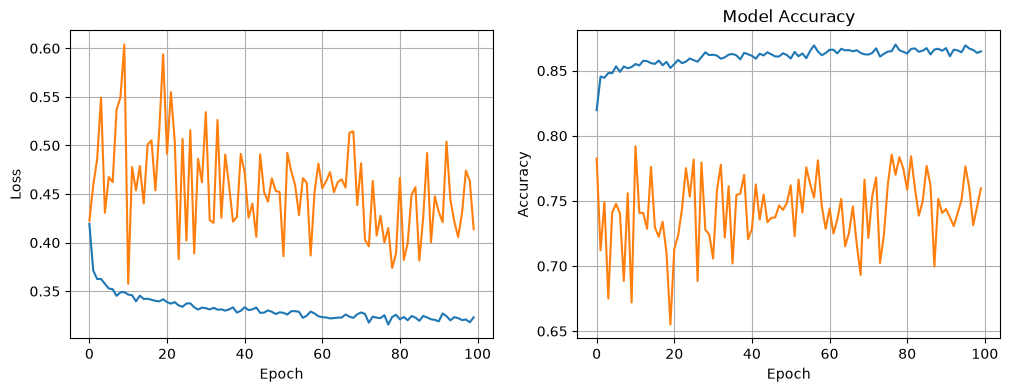

32 nodes, dropout: 0.2, lr: 0.01, batch_size: 64
Epoch 1/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 1s 800us/step - accuracy: 0.8066 - loss: 0.4322 - val_accuracy: 0.7384 - val_loss: 0.5251
Epoch 2/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 465us/step - accuracy: 0.8403 - loss: 0.3803 - val_accuracy: 0.7411 - val_loss: 0.4806
Epoch 3/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 406us/step - accuracy: 0.8484 - loss: 0.3633 - val_accuracy: 0.7084 - val_loss: 0.5496
Epoch 4/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 413us/step - accuracy: 0.8471 - loss: 0.3572 - val_accuracy: 0.6888 - val_loss: 0.5194
Epoch 5/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 406us/step - accuracy: 0.8488 - loss: 0.3572 - val_accuracy: 0.7569 - val_loss: 0.4452
Epoch 6/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 390us/step - accuracy: 0.8508 - loss: 0.3476 - val_accuracy: 0.7451 - val_loss: 0.4673
Epoch 7/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 482us/step - accuracy: 0.8517 - loss: 0.3460 - val_accuracy: 0.7798 - val_loss: 0.4147
Epoch 8/100
186/186 ━━━━━━━━━━━━━━

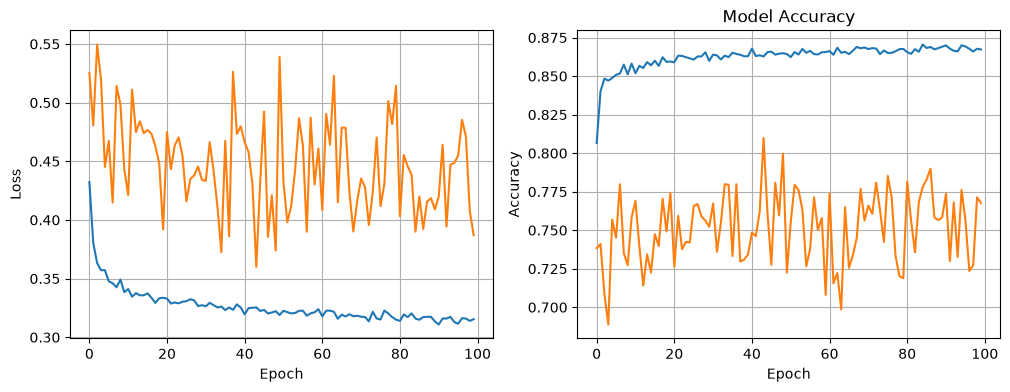

32 nodes, dropout: 0.2, lr: 0.01, batch_size: 128
Epoch 1/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7945 - loss: 0.4548 - val_accuracy: 0.7003 - val_loss: 0.5316
Epoch 2/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 578us/step - accuracy: 0.8346 - loss: 0.3902 - val_accuracy: 0.7738 - val_loss: 0.4558
Epoch 3/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 597us/step - accuracy: 0.8388 - loss: 0.3742 - val_accuracy: 0.7256 - val_loss: 0.5429
Epoch 4/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 571us/step - accuracy: 0.8508 - loss: 0.3563 - val_accuracy: 0.7566 - val_loss: 0.4541
Epoch 5/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 528us/step - accuracy: 0.8506 - loss: 0.3518 - val_accuracy: 0.7111 - val_loss: 0.5570
Epoch 6/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 563us/step - accuracy: 0.8506 - loss: 0.3500 - val_accuracy: 0.7556 - val_loss: 0.4534
Epoch 7/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 544us/step - accuracy: 0.8535 - loss: 0.3483 - val_accuracy: 0.7057 - val_loss: 0.5271
Epoch 8/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 578us/s

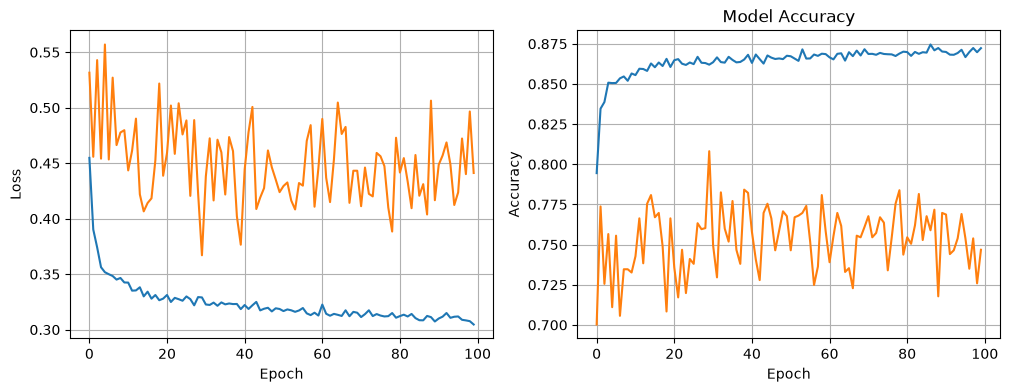

32 nodes, dropout: 0.2, lr: 0.0005, batch_size: 32
Epoch 1/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 564us/step - accuracy: 0.7252 - loss: 0.5491 - val_accuracy: 0.6349 - val_loss: 0.6315
Epoch 2/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 367us/step - accuracy: 0.7943 - loss: 0.4458 - val_accuracy: 0.6750 - val_loss: 0.5845
Epoch 3/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 357us/step - accuracy: 0.8052 - loss: 0.4286 - val_accuracy: 0.7013 - val_loss: 0.5410
Epoch 4/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 353us/step - accuracy: 0.8130 - loss: 0.4206 - val_accuracy: 0.6763 - val_loss: 0.5763
Epoch 5/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 345us/step - accuracy: 0.8173 - loss: 0.4126 - val_accuracy: 0.6770 - val_loss: 0.5973
Epoch 6/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 353us/step - accuracy: 0.8212 - loss: 0.4042 - val_accuracy: 0.6827 - val_loss: 0.5768
Epoch 7/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 354us/step - accuracy: 0.8278 - loss: 0.3997 - val_accuracy: 0.7043 - val_loss: 0.5591
Epoch 8/100
371/371 ━━━━━━━━━━━━

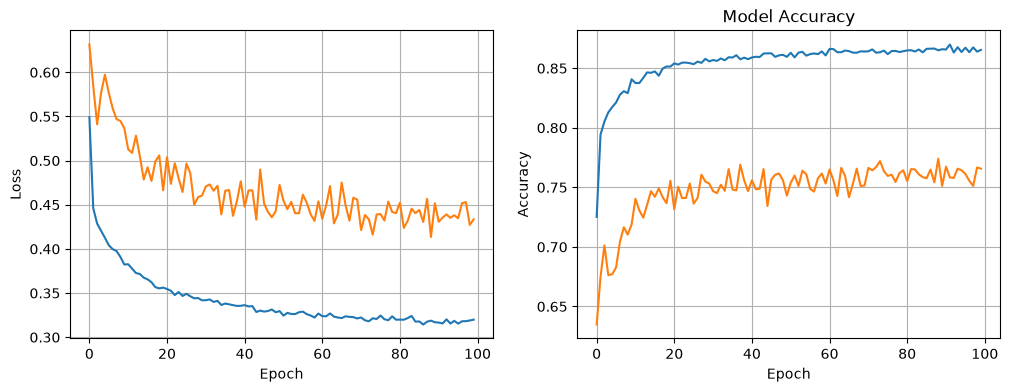

32 nodes, dropout: 0.2, lr: 0.0005, batch_size: 64
Epoch 1/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 1s 830us/step - accuracy: 0.6861 - loss: 0.6069 - val_accuracy: 0.5428 - val_loss: 0.6541
Epoch 2/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 424us/step - accuracy: 0.7756 - loss: 0.4847 - val_accuracy: 0.6129 - val_loss: 0.6423
Epoch 3/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 433us/step - accuracy: 0.7966 - loss: 0.4422 - val_accuracy: 0.6622 - val_loss: 0.5856
Epoch 4/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 421us/step - accuracy: 0.8083 - loss: 0.4314 - val_accuracy: 0.6585 - val_loss: 0.5949
Epoch 5/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 394us/step - accuracy: 0.8145 - loss: 0.4178 - val_accuracy: 0.6615 - val_loss: 0.5992
Epoch 6/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 407us/step - accuracy: 0.8185 - loss: 0.4105 - val_accuracy: 0.6743 - val_loss: 0.5735
Epoch 7/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 485us/step - accuracy: 0.8221 - loss: 0.4060 - val_accuracy: 0.6834 - val_loss: 0.5609
Epoch 8/100
186/186 ━━━━━━━━━━━━

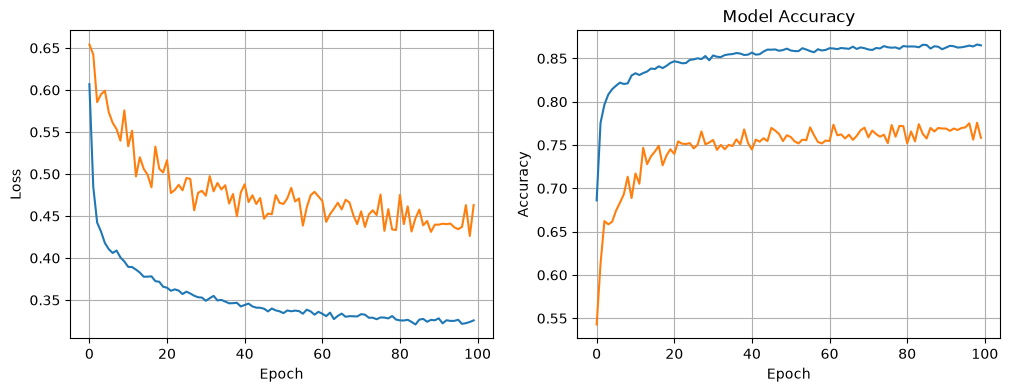

32 nodes, dropout: 0.2, lr: 0.0005, batch_size: 128
Epoch 1/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5992 - loss: 0.6619 - val_accuracy: 0.4882 - val_loss: 0.6679
Epoch 2/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 555us/step - accuracy: 0.7489 - loss: 0.5489 - val_accuracy: 0.5593 - val_loss: 0.6639
Epoch 3/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 551us/step - accuracy: 0.7728 - loss: 0.4829 - val_accuracy: 0.6069 - val_loss: 0.6408
Epoch 4/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 503us/step - accuracy: 0.7815 - loss: 0.4579 - val_accuracy: 0.6247 - val_loss: 0.6247
Epoch 5/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 512us/step - accuracy: 0.7947 - loss: 0.4411 - val_accuracy: 0.6423 - val_loss: 0.5895
Epoch 6/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 527us/step - accuracy: 0.8017 - loss: 0.4350 - val_accuracy: 0.6480 - val_loss: 0.5998
Epoch 7/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 525us/step - accuracy: 0.8065 - loss: 0.4290 - val_accuracy: 0.6743 - val_loss: 0.5749
Epoch 8/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 499us

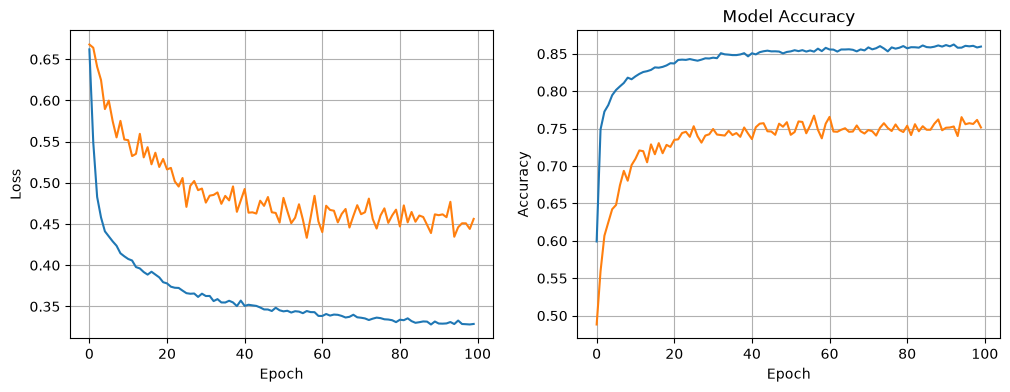

32 nodes, dropout: 0.2, lr: 0.001, batch_size: 32
Epoch 1/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 555us/step - accuracy: 0.7770 - loss: 0.4744 - val_accuracy: 0.6575 - val_loss: 0.5785
Epoch 2/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 370us/step - accuracy: 0.8098 - loss: 0.4159 - val_accuracy: 0.7077 - val_loss: 0.5510
Epoch 3/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 354us/step - accuracy: 0.8230 - loss: 0.4016 - val_accuracy: 0.6699 - val_loss: 0.6030
Epoch 4/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 362us/step - accuracy: 0.8312 - loss: 0.3925 - val_accuracy: 0.7006 - val_loss: 0.5529
Epoch 5/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 419us/step - accuracy: 0.8389 - loss: 0.3838 - val_accuracy: 0.7448 - val_loss: 0.4795
Epoch 6/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 354us/step - accuracy: 0.8393 - loss: 0.3753 - val_accuracy: 0.7333 - val_loss: 0.4943
Epoch 7/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 353us/step - accuracy: 0.8464 - loss: 0.3689 - val_accuracy: 0.7084 - val_loss: 0.5345
Epoch 8/100
371/371 ━━━━━━━━━━━━━

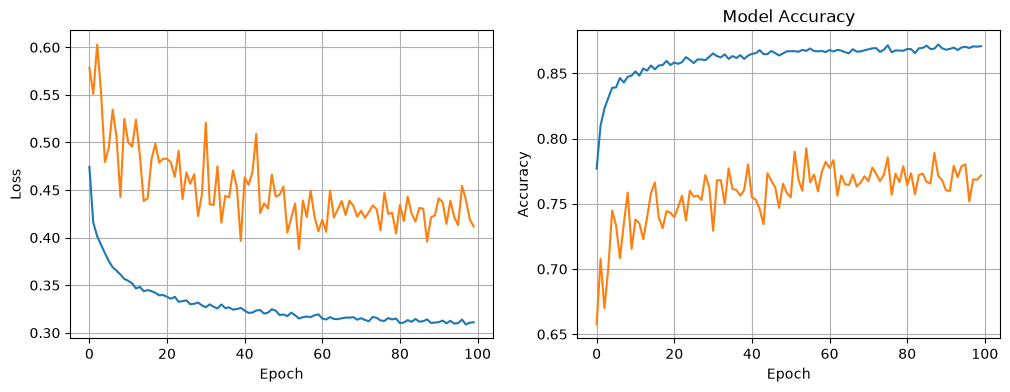

32 nodes, dropout: 0.2, lr: 0.001, batch_size: 64
Epoch 1/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 1s 800us/step - accuracy: 0.7213 - loss: 0.5502 - val_accuracy: 0.5968 - val_loss: 0.6444
Epoch 2/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 411us/step - accuracy: 0.7898 - loss: 0.4477 - val_accuracy: 0.6433 - val_loss: 0.6151
Epoch 3/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 387us/step - accuracy: 0.8083 - loss: 0.4265 - val_accuracy: 0.6959 - val_loss: 0.5472
Epoch 4/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 414us/step - accuracy: 0.8182 - loss: 0.4094 - val_accuracy: 0.7188 - val_loss: 0.5287
Epoch 5/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 407us/step - accuracy: 0.8268 - loss: 0.3996 - val_accuracy: 0.7020 - val_loss: 0.5629
Epoch 6/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 386us/step - accuracy: 0.8322 - loss: 0.3899 - val_accuracy: 0.7360 - val_loss: 0.5273
Epoch 7/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 386us/step - accuracy: 0.8369 - loss: 0.3773 - val_accuracy: 0.7363 - val_loss: 0.5127
Epoch 8/100
186/186 ━━━━━━━━━━━━━

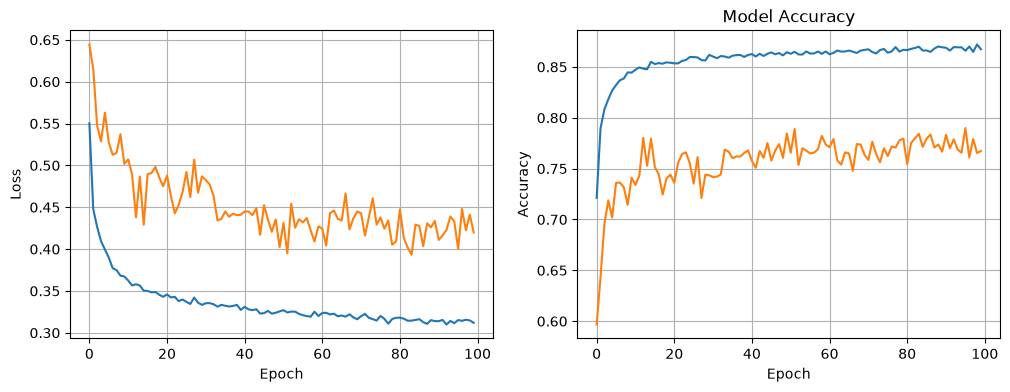

32 nodes, dropout: 0.2, lr: 0.001, batch_size: 128
Epoch 1/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6916 - loss: 0.5983 - val_accuracy: 0.5357 - val_loss: 0.6851
Epoch 2/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 734us/step - accuracy: 0.7752 - loss: 0.4706 - val_accuracy: 0.6281 - val_loss: 0.6353
Epoch 3/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 670us/step - accuracy: 0.7986 - loss: 0.4390 - val_accuracy: 0.6601 - val_loss: 0.5908
Epoch 4/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 767us/step - accuracy: 0.8077 - loss: 0.4288 - val_accuracy: 0.6632 - val_loss: 0.5884
Epoch 5/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 627us/step - accuracy: 0.8117 - loss: 0.4185 - val_accuracy: 0.6699 - val_loss: 0.5884
Epoch 6/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 630us/step - accuracy: 0.8209 - loss: 0.4074 - val_accuracy: 0.6726 - val_loss: 0.5952
Epoch 7/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 520us/step - accuracy: 0.8259 - loss: 0.4008 - val_accuracy: 0.6817 - val_loss: 0.5925
Epoch 8/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 505us/

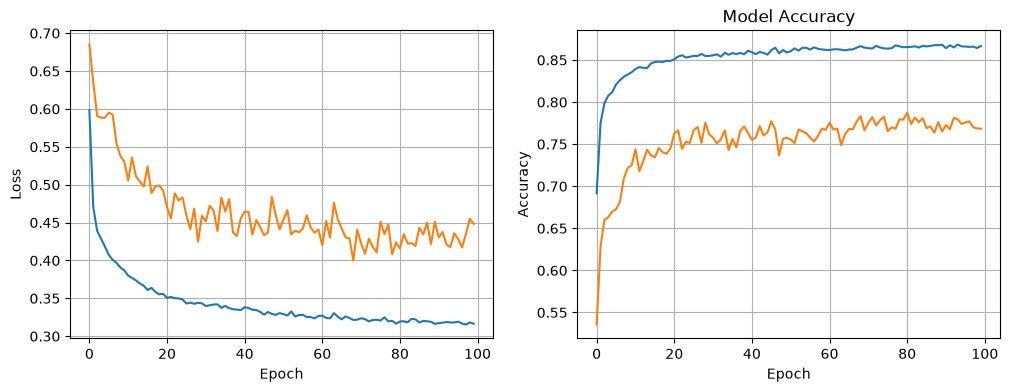

64 nodes, dropout: 0, lr: 0.01, batch_size: 32
Epoch 1/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 547us/step - accuracy: 0.8364 - loss: 0.3817 - val_accuracy: 0.7492 - val_loss: 0.4579
Epoch 2/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 343us/step - accuracy: 0.8529 - loss: 0.3474 - val_accuracy: 0.7546 - val_loss: 0.4436
Epoch 3/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 363us/step - accuracy: 0.8551 - loss: 0.3384 - val_accuracy: 0.7508 - val_loss: 0.5002
Epoch 4/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 354us/step - accuracy: 0.8595 - loss: 0.3323 - val_accuracy: 0.6955 - val_loss: 0.6059
Epoch 5/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 346us/step - accuracy: 0.8602 - loss: 0.3296 - val_accuracy: 0.8105 - val_loss: 0.3577
Epoch 6/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 391us/step - accuracy: 0.8645 - loss: 0.3228 - val_accuracy: 0.8004 - val_loss: 0.3968
Epoch 7/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 344us/step - accuracy: 0.8656 - loss: 0.3188 - val_accuracy: 0.7363 - val_loss: 0.4976
Epoch 8/100
371/371 ━━━━━━━━━━━━━━━━

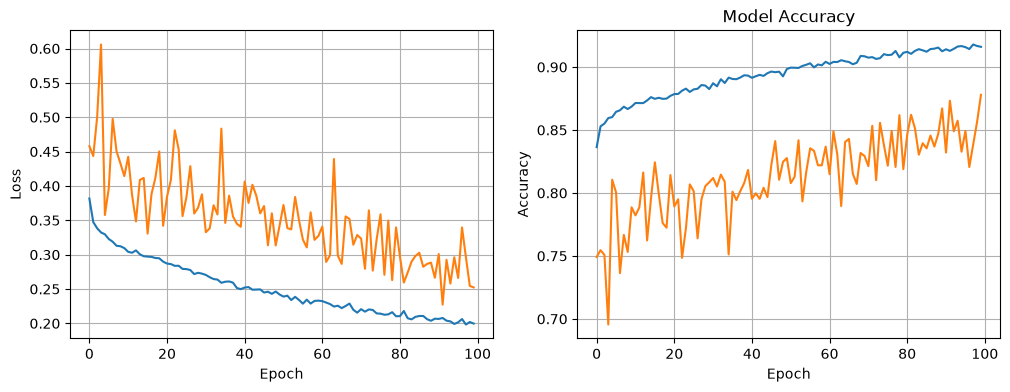

64 nodes, dropout: 0, lr: 0.01, batch_size: 64
Epoch 1/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 1s 774us/step - accuracy: 0.8279 - loss: 0.3880 - val_accuracy: 0.7458 - val_loss: 0.4401
Epoch 2/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 402us/step - accuracy: 0.8498 - loss: 0.3494 - val_accuracy: 0.8078 - val_loss: 0.3818
Epoch 3/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 401us/step - accuracy: 0.8576 - loss: 0.3370 - val_accuracy: 0.7839 - val_loss: 0.4259
Epoch 4/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 387us/step - accuracy: 0.8615 - loss: 0.3301 - val_accuracy: 0.7637 - val_loss: 0.4329
Epoch 5/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 387us/step - accuracy: 0.8647 - loss: 0.3219 - val_accuracy: 0.7748 - val_loss: 0.4405
Epoch 6/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 391us/step - accuracy: 0.8656 - loss: 0.3169 - val_accuracy: 0.7670 - val_loss: 0.4732
Epoch 7/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 409us/step - accuracy: 0.8656 - loss: 0.3178 - val_accuracy: 0.7643 - val_loss: 0.4628
Epoch 8/100
186/186 ━━━━━━━━━━━━━━━━

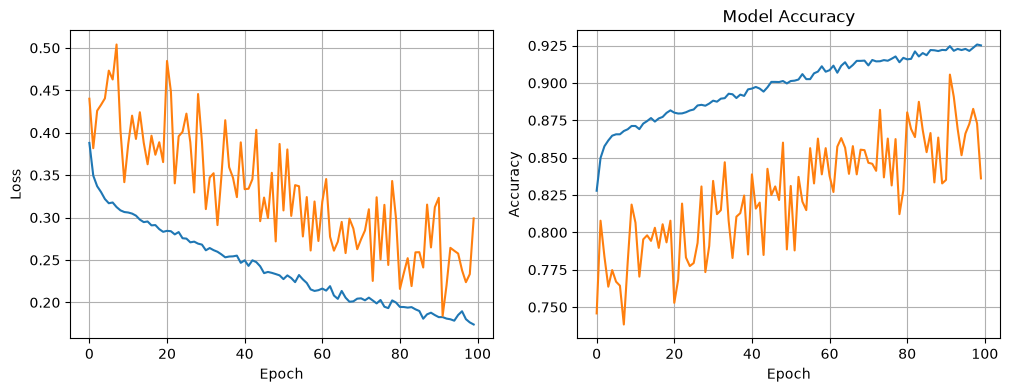

64 nodes, dropout: 0, lr: 0.01, batch_size: 128
Epoch 1/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8243 - loss: 0.4008 - val_accuracy: 0.7481 - val_loss: 0.4896
Epoch 2/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 544us/step - accuracy: 0.8519 - loss: 0.3505 - val_accuracy: 0.7343 - val_loss: 0.5128
Epoch 3/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 575us/step - accuracy: 0.8558 - loss: 0.3360 - val_accuracy: 0.6750 - val_loss: 0.6049
Epoch 4/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 528us/step - accuracy: 0.8635 - loss: 0.3278 - val_accuracy: 0.7178 - val_loss: 0.5865
Epoch 5/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 528us/step - accuracy: 0.8618 - loss: 0.3230 - val_accuracy: 0.7819 - val_loss: 0.4504
Epoch 6/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 488us/step - accuracy: 0.8644 - loss: 0.3223 - val_accuracy: 0.7967 - val_loss: 0.4027
Epoch 7/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 480us/step - accuracy: 0.8669 - loss: 0.3166 - val_accuracy: 0.7667 - val_loss: 0.4310
Epoch 8/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 481us/ste

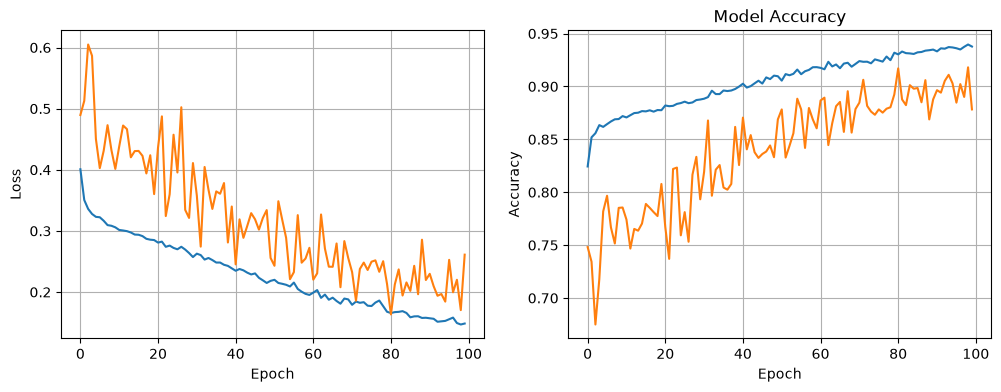

64 nodes, dropout: 0, lr: 0.0005, batch_size: 32
Epoch 1/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 551us/step - accuracy: 0.7937 - loss: 0.4522 - val_accuracy: 0.6713 - val_loss: 0.5956
Epoch 2/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 343us/step - accuracy: 0.8345 - loss: 0.3829 - val_accuracy: 0.7262 - val_loss: 0.5159
Epoch 3/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 342us/step - accuracy: 0.8487 - loss: 0.3606 - val_accuracy: 0.7350 - val_loss: 0.5265
Epoch 4/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 373us/step - accuracy: 0.8528 - loss: 0.3500 - val_accuracy: 0.7572 - val_loss: 0.4787
Epoch 5/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 404us/step - accuracy: 0.8572 - loss: 0.3426 - val_accuracy: 0.7579 - val_loss: 0.4725
Epoch 6/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 389us/step - accuracy: 0.8573 - loss: 0.3367 - val_accuracy: 0.7444 - val_loss: 0.4947
Epoch 7/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 361us/step - accuracy: 0.8598 - loss: 0.3326 - val_accuracy: 0.7734 - val_loss: 0.4377
Epoch 8/100
371/371 ━━━━━━━━━━━━━━

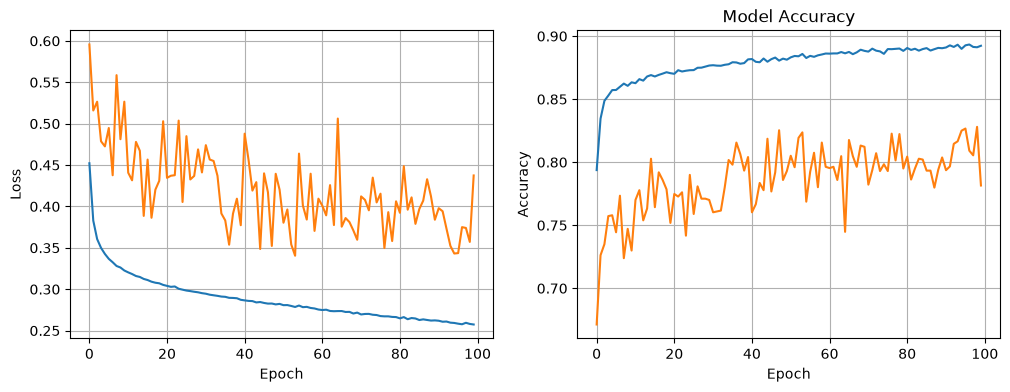

64 nodes, dropout: 0, lr: 0.0005, batch_size: 64
Epoch 1/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 1s 788us/step - accuracy: 0.7762 - loss: 0.4890 - val_accuracy: 0.6888 - val_loss: 0.5383
Epoch 2/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 463us/step - accuracy: 0.8238 - loss: 0.3980 - val_accuracy: 0.6598 - val_loss: 0.5917
Epoch 3/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 461us/step - accuracy: 0.8413 - loss: 0.3758 - val_accuracy: 0.7188 - val_loss: 0.5286
Epoch 4/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 429us/step - accuracy: 0.8504 - loss: 0.3622 - val_accuracy: 0.7363 - val_loss: 0.5109
Epoch 5/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 422us/step - accuracy: 0.8536 - loss: 0.3542 - val_accuracy: 0.7421 - val_loss: 0.5002
Epoch 6/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 433us/step - accuracy: 0.8554 - loss: 0.3481 - val_accuracy: 0.7505 - val_loss: 0.4938
Epoch 7/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 396us/step - accuracy: 0.8593 - loss: 0.3429 - val_accuracy: 0.7559 - val_loss: 0.4804
Epoch 8/100
186/186 ━━━━━━━━━━━━━━

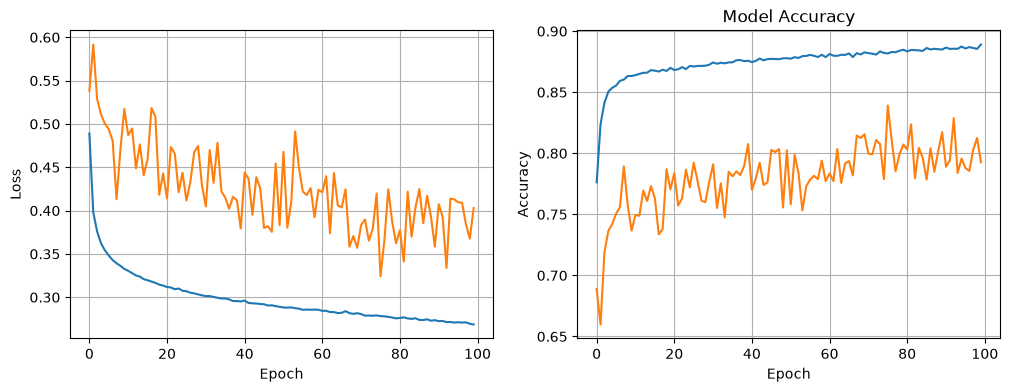

64 nodes, dropout: 0, lr: 0.0005, batch_size: 128
Epoch 1/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7120 - loss: 0.5702 - val_accuracy: 0.6372 - val_loss: 0.5894
Epoch 2/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 581us/step - accuracy: 0.8058 - loss: 0.4311 - val_accuracy: 0.6365 - val_loss: 0.6181
Epoch 3/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 491us/step - accuracy: 0.8240 - loss: 0.3949 - val_accuracy: 0.6605 - val_loss: 0.6054
Epoch 4/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 510us/step - accuracy: 0.8364 - loss: 0.3794 - val_accuracy: 0.7016 - val_loss: 0.5638
Epoch 5/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 478us/step - accuracy: 0.8435 - loss: 0.3692 - val_accuracy: 0.7411 - val_loss: 0.5009
Epoch 6/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 493us/step - accuracy: 0.8506 - loss: 0.3604 - val_accuracy: 0.7370 - val_loss: 0.5127
Epoch 7/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 511us/step - accuracy: 0.8516 - loss: 0.3538 - val_accuracy: 0.7252 - val_loss: 0.5439
Epoch 8/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 492us/s

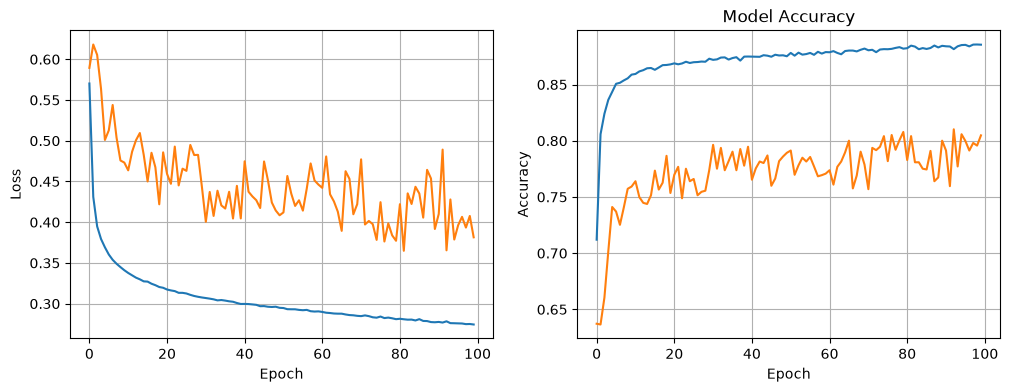

64 nodes, dropout: 0, lr: 0.001, batch_size: 32
Epoch 1/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 584us/step - accuracy: 0.8050 - loss: 0.4296 - val_accuracy: 0.7232 - val_loss: 0.5129
Epoch 2/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 358us/step - accuracy: 0.8444 - loss: 0.3646 - val_accuracy: 0.7239 - val_loss: 0.5425
Epoch 3/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 342us/step - accuracy: 0.8554 - loss: 0.3465 - val_accuracy: 0.7525 - val_loss: 0.4720
Epoch 4/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 357us/step - accuracy: 0.8579 - loss: 0.3373 - val_accuracy: 0.7313 - val_loss: 0.5110
Epoch 5/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 350us/step - accuracy: 0.8616 - loss: 0.3296 - val_accuracy: 0.7792 - val_loss: 0.4157
Epoch 6/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 348us/step - accuracy: 0.8639 - loss: 0.3255 - val_accuracy: 0.7667 - val_loss: 0.4301
Epoch 7/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 346us/step - accuracy: 0.8656 - loss: 0.3207 - val_accuracy: 0.7613 - val_loss: 0.4691
Epoch 8/100
371/371 ━━━━━━━━━━━━━━━

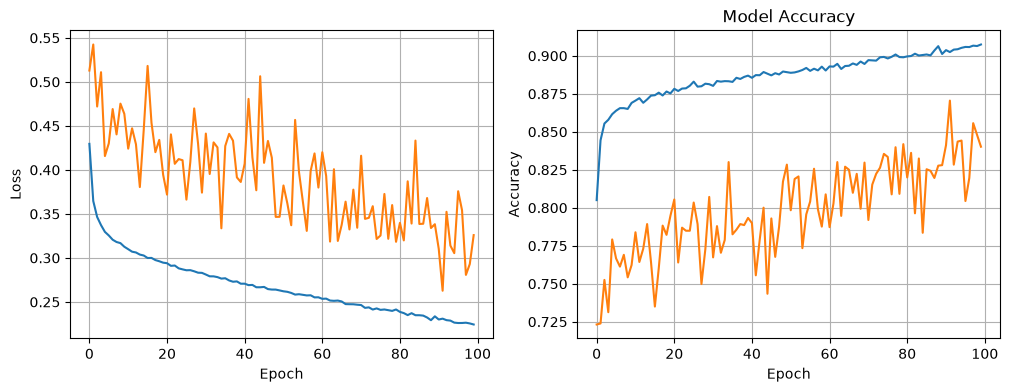

64 nodes, dropout: 0, lr: 0.001, batch_size: 64
Epoch 1/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 1s 834us/step - accuracy: 0.7940 - loss: 0.4554 - val_accuracy: 0.7168 - val_loss: 0.5279
Epoch 2/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 433us/step - accuracy: 0.8376 - loss: 0.3763 - val_accuracy: 0.7572 - val_loss: 0.4630
Epoch 3/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 440us/step - accuracy: 0.8533 - loss: 0.3558 - val_accuracy: 0.7633 - val_loss: 0.4553
Epoch 4/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 514us/step - accuracy: 0.8561 - loss: 0.3441 - val_accuracy: 0.7363 - val_loss: 0.5071
Epoch 5/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 511us/step - accuracy: 0.8599 - loss: 0.3360 - val_accuracy: 0.7647 - val_loss: 0.4579
Epoch 6/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 633us/step - accuracy: 0.8619 - loss: 0.3308 - val_accuracy: 0.7417 - val_loss: 0.5058
Epoch 7/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 506us/step - accuracy: 0.8627 - loss: 0.3261 - val_accuracy: 0.7502 - val_loss: 0.4800
Epoch 8/100
186/186 ━━━━━━━━━━━━━━━

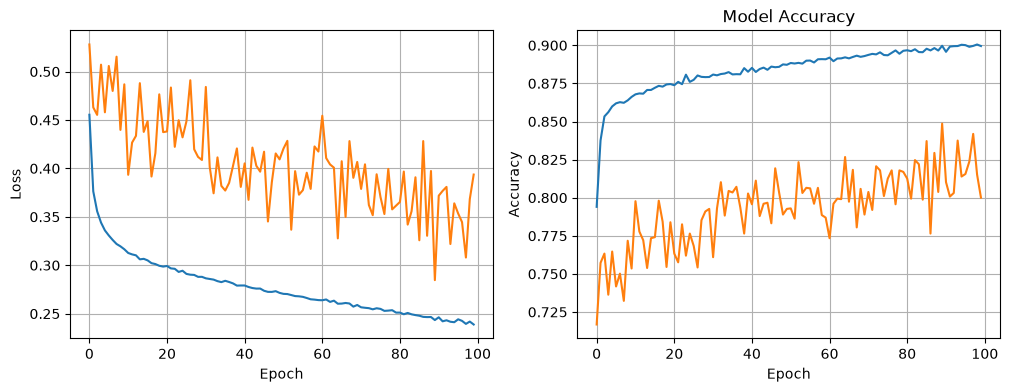

64 nodes, dropout: 0, lr: 0.001, batch_size: 128
Epoch 1/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7569 - loss: 0.5004 - val_accuracy: 0.6436 - val_loss: 0.5926
Epoch 2/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 526us/step - accuracy: 0.8254 - loss: 0.3918 - val_accuracy: 0.7073 - val_loss: 0.5306
Epoch 3/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 539us/step - accuracy: 0.8420 - loss: 0.3673 - val_accuracy: 0.7451 - val_loss: 0.4868
Epoch 4/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 533us/step - accuracy: 0.8516 - loss: 0.3539 - val_accuracy: 0.7330 - val_loss: 0.5130
Epoch 5/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 539us/step - accuracy: 0.8553 - loss: 0.3443 - val_accuracy: 0.7667 - val_loss: 0.4520
Epoch 6/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 534us/step - accuracy: 0.8582 - loss: 0.3384 - val_accuracy: 0.7674 - val_loss: 0.4536
Epoch 7/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 488us/step - accuracy: 0.8606 - loss: 0.3318 - val_accuracy: 0.7390 - val_loss: 0.4994
Epoch 8/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 660us/st

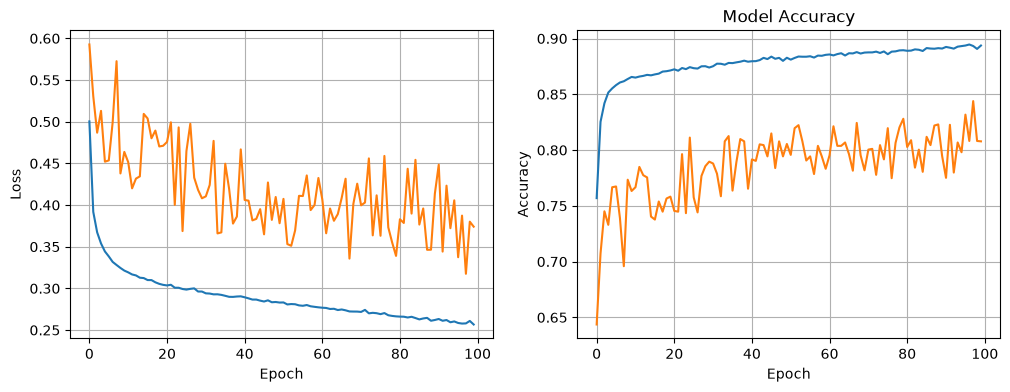

64 nodes, dropout: 0.2, lr: 0.01, batch_size: 32
Epoch 1/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 579us/step - accuracy: 0.8217 - loss: 0.4096 - val_accuracy: 0.6497 - val_loss: 0.6193
Epoch 2/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 391us/step - accuracy: 0.8442 - loss: 0.3684 - val_accuracy: 0.7360 - val_loss: 0.4986
Epoch 3/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 386us/step - accuracy: 0.8534 - loss: 0.3554 - val_accuracy: 0.7542 - val_loss: 0.4027
Epoch 4/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 435us/step - accuracy: 0.8505 - loss: 0.3510 - val_accuracy: 0.7653 - val_loss: 0.4203
Epoch 5/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 402us/step - accuracy: 0.8552 - loss: 0.3482 - val_accuracy: 0.6561 - val_loss: 0.5740
Epoch 6/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 385us/step - accuracy: 0.8527 - loss: 0.3495 - val_accuracy: 0.7094 - val_loss: 0.5294
Epoch 7/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 385us/step - accuracy: 0.8556 - loss: 0.3431 - val_accuracy: 0.7131 - val_loss: 0.5266
Epoch 8/100
371/371 ━━━━━━━━━━━━━━

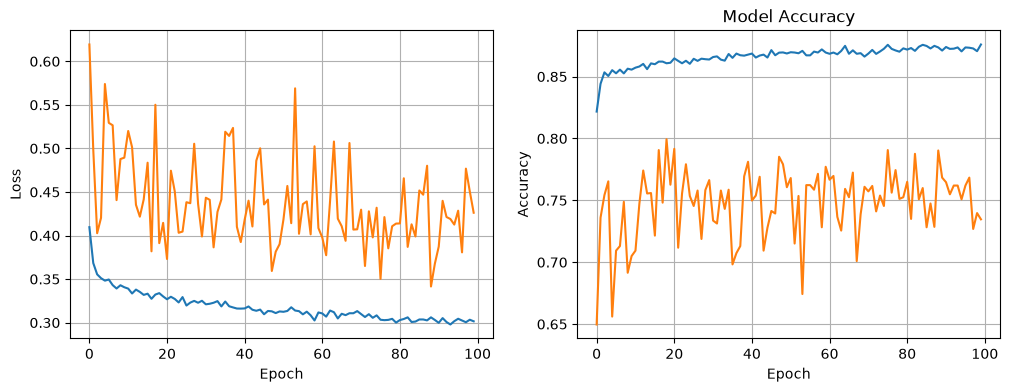

64 nodes, dropout: 0.2, lr: 0.01, batch_size: 64
Epoch 1/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 1s 893us/step - accuracy: 0.8163 - loss: 0.4159 - val_accuracy: 0.6591 - val_loss: 0.6939
Epoch 2/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 440us/step - accuracy: 0.8397 - loss: 0.3696 - val_accuracy: 0.7030 - val_loss: 0.4961
Epoch 3/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 448us/step - accuracy: 0.8517 - loss: 0.3552 - val_accuracy: 0.7185 - val_loss: 0.5033
Epoch 4/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 435us/step - accuracy: 0.8533 - loss: 0.3474 - val_accuracy: 0.7728 - val_loss: 0.4769
Epoch 5/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 454us/step - accuracy: 0.8531 - loss: 0.3486 - val_accuracy: 0.7262 - val_loss: 0.5921
Epoch 6/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 423us/step - accuracy: 0.8567 - loss: 0.3397 - val_accuracy: 0.7481 - val_loss: 0.4470
Epoch 7/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 421us/step - accuracy: 0.8574 - loss: 0.3413 - val_accuracy: 0.7883 - val_loss: 0.4224
Epoch 8/100
186/186 ━━━━━━━━━━━━━━

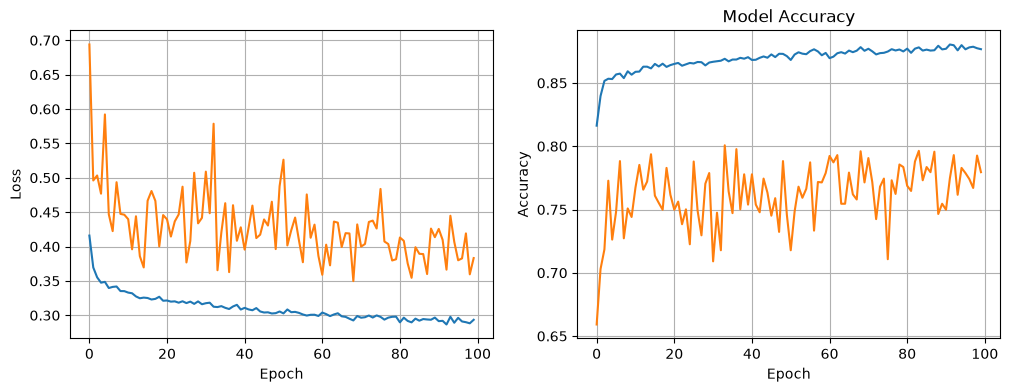

64 nodes, dropout: 0.2, lr: 0.01, batch_size: 128
Epoch 1/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8065 - loss: 0.4269 - val_accuracy: 0.6979 - val_loss: 0.5424
Epoch 2/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 648us/step - accuracy: 0.8393 - loss: 0.3731 - val_accuracy: 0.6689 - val_loss: 0.5698
Epoch 3/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 629us/step - accuracy: 0.8511 - loss: 0.3548 - val_accuracy: 0.6841 - val_loss: 0.5654
Epoch 4/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 577us/step - accuracy: 0.8564 - loss: 0.3457 - val_accuracy: 0.7664 - val_loss: 0.4371
Epoch 5/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 566us/step - accuracy: 0.8555 - loss: 0.3426 - val_accuracy: 0.6959 - val_loss: 0.5325
Epoch 6/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 578us/step - accuracy: 0.8570 - loss: 0.3415 - val_accuracy: 0.7310 - val_loss: 0.4715
Epoch 7/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 683us/step - accuracy: 0.8586 - loss: 0.3351 - val_accuracy: 0.6895 - val_loss: 0.5084
Epoch 8/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 608us/s

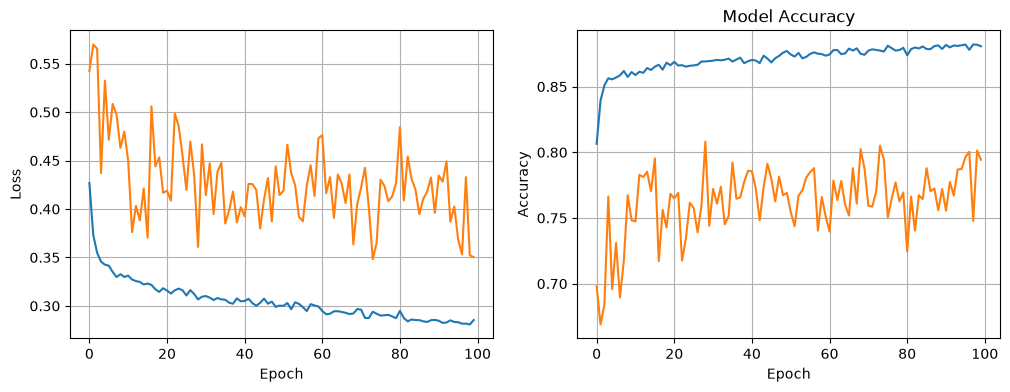

64 nodes, dropout: 0.2, lr: 0.0005, batch_size: 32
Epoch 1/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 580us/step - accuracy: 0.7738 - loss: 0.4847 - val_accuracy: 0.6514 - val_loss: 0.6078
Epoch 2/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 376us/step - accuracy: 0.8184 - loss: 0.4116 - val_accuracy: 0.6696 - val_loss: 0.5844
Epoch 3/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 384us/step - accuracy: 0.8275 - loss: 0.3960 - val_accuracy: 0.7090 - val_loss: 0.5258
Epoch 4/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 379us/step - accuracy: 0.8353 - loss: 0.3842 - val_accuracy: 0.7107 - val_loss: 0.5325
Epoch 5/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 379us/step - accuracy: 0.8420 - loss: 0.3756 - val_accuracy: 0.7077 - val_loss: 0.5522
Epoch 6/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 394us/step - accuracy: 0.8445 - loss: 0.3692 - val_accuracy: 0.7310 - val_loss: 0.5177
Epoch 7/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 382us/step - accuracy: 0.8470 - loss: 0.3615 - val_accuracy: 0.7505 - val_loss: 0.4776
Epoch 8/100
371/371 ━━━━━━━━━━━━

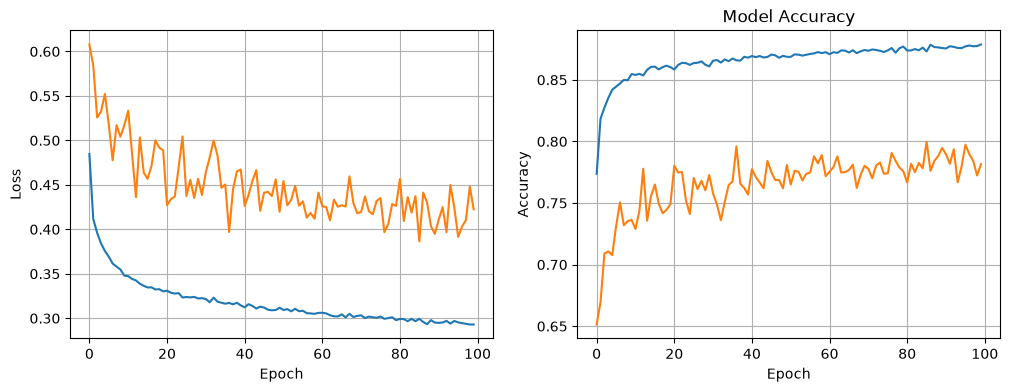

64 nodes, dropout: 0.2, lr: 0.0005, batch_size: 64
Epoch 1/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 1s 869us/step - accuracy: 0.7411 - loss: 0.5426 - val_accuracy: 0.6537 - val_loss: 0.6072
Epoch 2/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 491us/step - accuracy: 0.8045 - loss: 0.4312 - val_accuracy: 0.6841 - val_loss: 0.5579
Epoch 3/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 481us/step - accuracy: 0.8127 - loss: 0.4149 - val_accuracy: 0.7050 - val_loss: 0.5341
Epoch 4/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 469us/step - accuracy: 0.8205 - loss: 0.4002 - val_accuracy: 0.7127 - val_loss: 0.5458
Epoch 5/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 485us/step - accuracy: 0.8286 - loss: 0.3950 - val_accuracy: 0.7269 - val_loss: 0.5296
Epoch 6/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 465us/step - accuracy: 0.8345 - loss: 0.3839 - val_accuracy: 0.7434 - val_loss: 0.5062
Epoch 7/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 447us/step - accuracy: 0.8344 - loss: 0.3796 - val_accuracy: 0.7401 - val_loss: 0.5064
Epoch 8/100
186/186 ━━━━━━━━━━━━

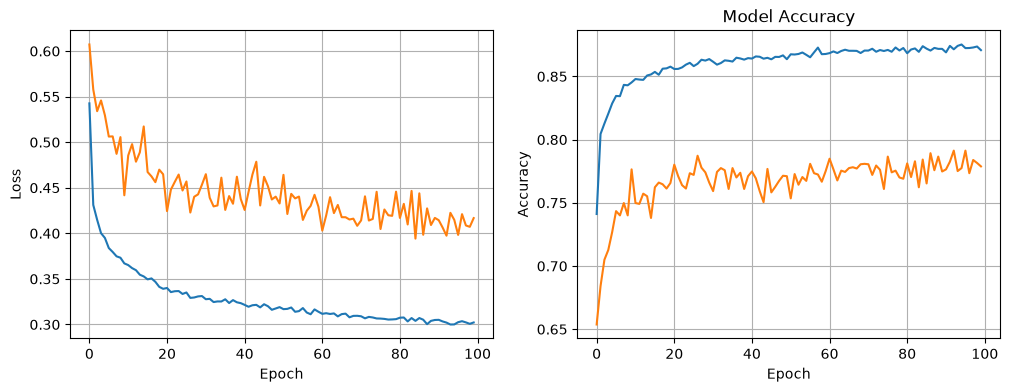

64 nodes, dropout: 0.2, lr: 0.0005, batch_size: 128
Epoch 1/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7208 - loss: 0.5755 - val_accuracy: 0.6167 - val_loss: 0.6291
Epoch 2/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 590us/step - accuracy: 0.7952 - loss: 0.4488 - val_accuracy: 0.6497 - val_loss: 0.5895
Epoch 3/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 698us/step - accuracy: 0.8066 - loss: 0.4272 - val_accuracy: 0.6487 - val_loss: 0.5933
Epoch 4/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 591us/step - accuracy: 0.8148 - loss: 0.4122 - val_accuracy: 0.6642 - val_loss: 0.5845
Epoch 5/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 589us/step - accuracy: 0.8181 - loss: 0.4067 - val_accuracy: 0.6807 - val_loss: 0.5578
Epoch 6/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 580us/step - accuracy: 0.8259 - loss: 0.3988 - val_accuracy: 0.6966 - val_loss: 0.5536
Epoch 7/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 583us/step - accuracy: 0.8283 - loss: 0.3948 - val_accuracy: 0.7013 - val_loss: 0.5547
Epoch 8/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 572us

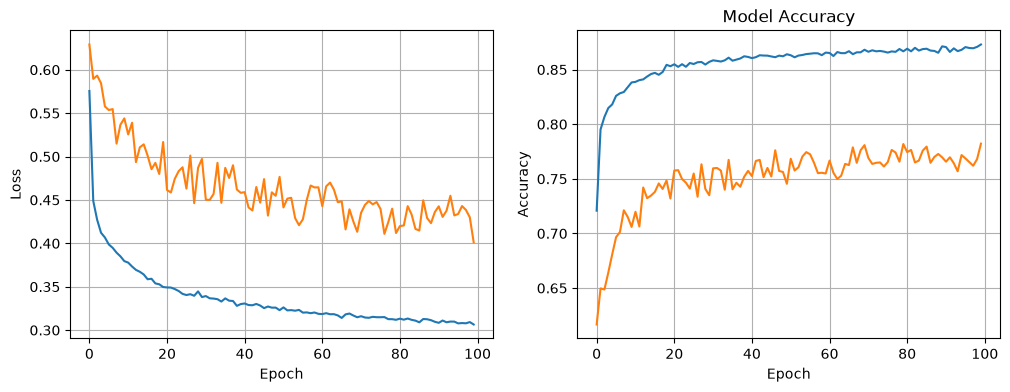

64 nodes, dropout: 0.2, lr: 0.001, batch_size: 32
Epoch 1/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 577us/step - accuracy: 0.7871 - loss: 0.4581 - val_accuracy: 0.7070 - val_loss: 0.5213
Epoch 2/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 374us/step - accuracy: 0.8255 - loss: 0.3934 - val_accuracy: 0.6966 - val_loss: 0.5570
Epoch 3/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 435us/step - accuracy: 0.8410 - loss: 0.3752 - val_accuracy: 0.7535 - val_loss: 0.4720
Epoch 4/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 382us/step - accuracy: 0.8462 - loss: 0.3636 - val_accuracy: 0.7272 - val_loss: 0.5412
Epoch 5/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 383us/step - accuracy: 0.8510 - loss: 0.3540 - val_accuracy: 0.7431 - val_loss: 0.4942
Epoch 6/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 374us/step - accuracy: 0.8498 - loss: 0.3485 - val_accuracy: 0.7367 - val_loss: 0.5138
Epoch 7/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 372us/step - accuracy: 0.8512 - loss: 0.3490 - val_accuracy: 0.7340 - val_loss: 0.5262
Epoch 8/100
371/371 ━━━━━━━━━━━━━

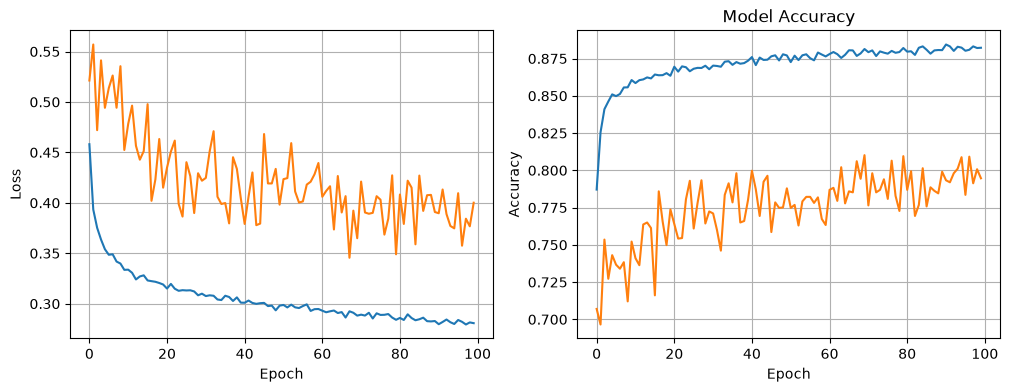

64 nodes, dropout: 0.2, lr: 0.001, batch_size: 64
Epoch 1/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 1s 887us/step - accuracy: 0.7751 - loss: 0.4808 - val_accuracy: 0.6696 - val_loss: 0.5668
Epoch 2/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 568us/step - accuracy: 0.8189 - loss: 0.4060 - val_accuracy: 0.7252 - val_loss: 0.5097
Epoch 3/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 543us/step - accuracy: 0.8320 - loss: 0.3865 - val_accuracy: 0.7310 - val_loss: 0.5058
Epoch 4/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 523us/step - accuracy: 0.8386 - loss: 0.3751 - val_accuracy: 0.7100 - val_loss: 0.5707
Epoch 5/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 596us/step - accuracy: 0.8449 - loss: 0.3633 - val_accuracy: 0.7444 - val_loss: 0.4844
Epoch 6/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 523us/step - accuracy: 0.8489 - loss: 0.3587 - val_accuracy: 0.7353 - val_loss: 0.5020
Epoch 7/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 530us/step - accuracy: 0.8495 - loss: 0.3559 - val_accuracy: 0.7175 - val_loss: 0.5302
Epoch 8/100
186/186 ━━━━━━━━━━━━━

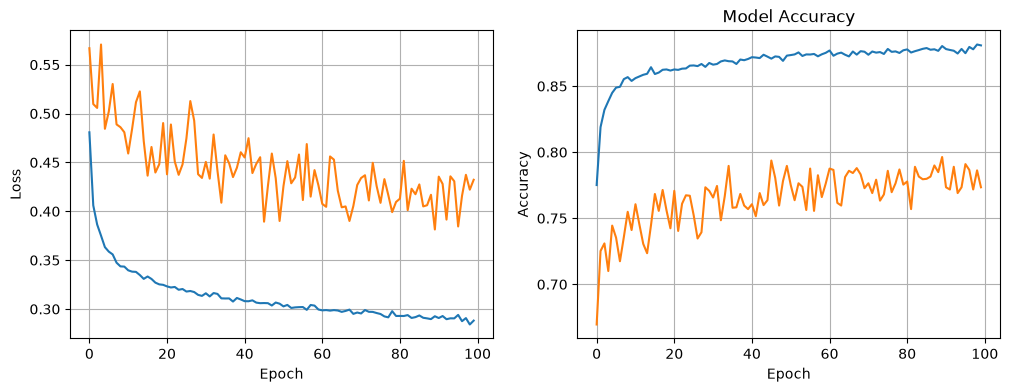

64 nodes, dropout: 0.2, lr: 0.001, batch_size: 128
Epoch 1/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7567 - loss: 0.5110 - val_accuracy: 0.6288 - val_loss: 0.6324
Epoch 2/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 618us/step - accuracy: 0.8069 - loss: 0.4253 - val_accuracy: 0.6460 - val_loss: 0.6240
Epoch 3/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 640us/step - accuracy: 0.8188 - loss: 0.4042 - val_accuracy: 0.6507 - val_loss: 0.6113
Epoch 4/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 620us/step - accuracy: 0.8307 - loss: 0.3865 - val_accuracy: 0.7279 - val_loss: 0.5294
Epoch 5/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 646us/step - accuracy: 0.8366 - loss: 0.3819 - val_accuracy: 0.7188 - val_loss: 0.5321
Epoch 6/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 620us/step - accuracy: 0.8458 - loss: 0.3721 - val_accuracy: 0.7326 - val_loss: 0.5133
Epoch 7/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 612us/step - accuracy: 0.8454 - loss: 0.3644 - val_accuracy: 0.7465 - val_loss: 0.4986
Epoch 8/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 577us/

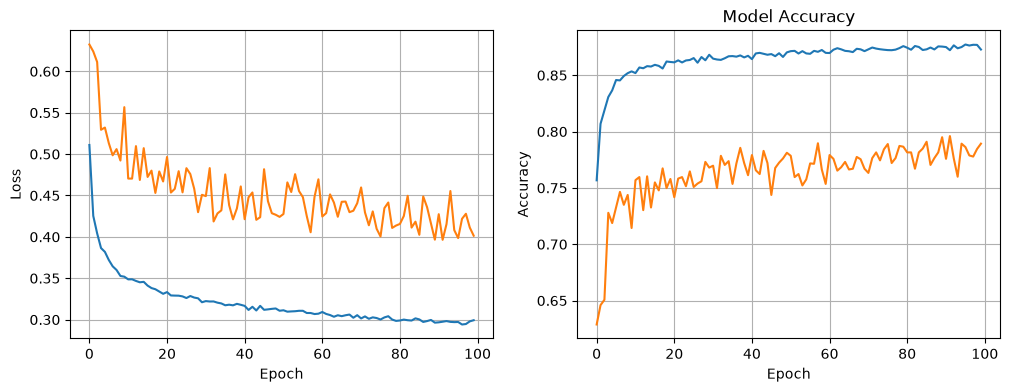

In [66]:
least_val_loss = float('inf')
least_loss_model = None
epochs = 100

for num_nodes in [16,32,64]:
    for dropout_prob in [0, 0.2]:
        for lr in [0.01, 0.0005, 0.001]:
            for batch_size in [32, 64, 128]:
                print(f"{num_nodes} nodes, dropout: {dropout_prob}, lr: {lr}, batch_size: {batch_size}")
                model, history = train_model(X_train, y_train, num_nodes, dropout_prob, lr, batch_size, epochs)
                plot_history(history)
                val_loss, val_accuracy = model.evaluate(X_valid, y_valid, verbose=0)
                if val_loss < least_val_loss:
                    least_val_loss = val_loss
                    least_loss_model = model

**What `.predict(X_test)` returns:** because the output layer is a single neuron with a `sigmoid` activation, this returns a NumPy array of shape `(n_samples, 1)` — one value per test row, each a float between 0 and 1 representing the model's estimated probability that the sample is class `1` (gamma). A value near 1 means the model is confident it's gamma; near 0 means confident hadron; near 0.5 means the model is unsure. These are raw probabilities, not hard labels — to get 0/1 predictions comparable to `y_test` (for a `classification_report` like the other models), threshold them, e.g. `(least_loss_model.predict(X_test) > 0.5).astype(int)`.

In [67]:
least_loss_model.predict(X_test)

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 274us/step


array([[0.00271196],
       [0.9446219 ],
       [0.42679173],
       ...,
       [0.9807147 ],
       [0.9682841 ],
       [0.33540353]], shape=(3804, 1), dtype=float32)

#### training the model

In [73]:
y_pred = least_loss_model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int).reshape(-1)
y_pred

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 235us/step


array([0, 1, 0, ..., 1, 1, 0], shape=(3804,))

*Observation* — the tuned network (from the hyperparameter sweep) achieves 0.87 accuracy, matching SVM overall, with strong balance in both classes (0.89 precision / 0.73 recall hadron, 0.87 precision / 0.95 recall gamma). It's a marked improvement over the earlier untuned KNN/Naive Bayes results, and comparable to SVM — but note the "training the model" heading above this cell is a bit misleading; the actual `.fit()` training already happened earlier in the hyperparameter sweep cell. This cell just applies the 0.5 threshold to `least_loss_model`'s predictions.

In [74]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.73      0.80      1337
           1       0.87      0.95      0.91      2467

    accuracy                           0.87      3804
   macro avg       0.88      0.84      0.85      3804
weighted avg       0.87      0.87      0.87      3804



In [77]:
#### this shows that neural nets are cool and fancy , but sometimes, SVMs or other models are more approrpiate